# Hypothesis 1 And Concept-Copying Analysis (parametric)

Mirror of `result_analysis.ipynb` driven by two knobs in the setup cell:

- `MODEL_NAME` — selects the model whose cache to load (e.g. `"Qwen3-8B"`, `"Olmo-3-1025-7B"`, `"Llama-3.1-8B"`).
- `INDEX_TYPE` — selects which previous-context positions count as the p2 target: `"p2_context"` (all positions where the suffix token appears in the prior block, default) or `"p2_prev"` (the single position immediately before p1). Requires running `improbable_bigram_scores.py --index-type <value>` for that run dir first.
- `WEIGHTED` — flips between *raw* attention scores (`ntm_raw`/`ltm_raw`, sum of attention probabilities) and *value-weighted* scores (`ntm_value_weighted`/`ltm_value_weighted`, attn × value-norm, renormalized). The flag flows through every summary, plot, heatmap, and interpretation markdown downstream.

The notebook loads:

- `cache/improbable_bigrams/{MODEL_NAME}/updated_table1_literal/` — improbable bigrams
- `cache/improbable_bigrams/{MODEL_NAME}/selected_two_token_concepts/` — coherent 2-token concept control
- `cache/improbable_bigrams/{MODEL_NAME}/random_tokens/` — random two-token phrase control
- `cache/causal_scores/{MODEL_NAME}/{concept_copying,token_copying}_len30_n1024.json` — head rankings (Section 2)

To switch settings, edit `MODEL_NAME`, `WEIGHTED`, and/or `INDEX_TYPE` in the setup cell and re-run all cells. Figure save dirs derive from `MODEL_SLUG`; figure filenames pick up `_raw`/`_weighted` suffixes so the variants don't overwrite each other.

In [42]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path) -> Path:
    candidates = []
    for candidate in (start, *start.parents):
        candidates.extend(
            [
                candidate,
                candidate / "dual-route-induction",
                candidate / "improbable-bigram-causality" / "dual-route-induction",
            ]
        )
    for candidate in candidates:
        if (candidate / "cache").exists() and (candidate / "scripts").exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Could not locate the dual-route-induction repo root from the current working directory."
    )


ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(ROOT / "scripts"))

import analysis_utils as h1

h1 = importlib.reload(h1)

h1.configure_matplotlib()

# One knob drives the whole notebook. Flip MODEL_NAME and re-run all cells to
# switch between models — figure dirs and cache lookups derive from this.
# MODEL_NAME = "Llama-3.1-8B"  # e.g. "Olmo-3-1025-7B"
# MODEL_NAME = "Olmo-3-1025-7B"  # e.g. "Olmo-3-1025-7B"
MODEL_NAME = "Qwen3-8B"
MODEL_SLUG = MODEL_NAME.lower().replace("-", "_").replace(".", "_")

# Toggle between raw NTM/LTM (sum of attention probabilities) and value-weighted
# NTM/LTM (attn × value-norm, renormalized). Affects every summary, plot, and
# heatmap downstream. Figure filenames pick up a suffix so the two variants
# don't overwrite each other on disk.
WEIGHTED = True
WEIGHTED_TAG = "weighted" if WEIGHTED else "raw"

# Toggle between p2_context (all previous-context positions where the
# suffix token appears) and p2_prev (the single position immediately
# before p1). Runs improbable_bigram_scores.py --index-type <value> first.
INDEX_TYPE = "p2_prev"  # or "p2_prev"

# Set to "multiscript_table1_literal" once the multiscript pipeline has been run
# (sbatch slurm/slurm_multiscript_pipeline.sh [--model <MODEL>]).
# Set to None to omit the multiscript condition from plots.
MULTISCRIPT_RUN = "multiscript_table1_literal"

CACHE = h1.load_cache(ROOT, model_name=MODEL_NAME, index_type=INDEX_TYPE, multiscript_run=MULTISCRIPT_RUN)
DEFAULT_TOP_K = 32
ROOT

PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction')

## Shared Cache Checks

Verify that the traced cache and both control caches are available before either analysis section.

In [43]:
display(Markdown(h1.trace_consistency_markdown(CACHE)))
overview = h1.dataset_overview(CACHE)
display(overview)

### Trace Consistency
The prompt-summary JSON is not present in this repo snapshot. The notebook therefore uses the traced cache directly.

,dataset,examples,hallucinated_second_token,copied
0,Improbable summary,85,29,56
1,Updated trace cache,85,29,56
2,2-token concept cache,36,0,36
3,Random phrase cache,35,0,35


# Hypothesis 1 Analysis

Token-induction diagnostics for Qwen3-8B on the improbable-bigram repetition setup:

- token induction heads should keep attending to the desired earlier suffix token, measured with `NTM`
- token induction heads should keep contributing to the correct second-token prediction, measured with `DLA`

Improbable trace lives in `updated_table1_literal/`; controls in `selected_two_token_concepts/` and `random_tokens/`.

In [44]:
summary = h1.build_pairwise_summary(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)
display(summary.round(6))
display(Markdown(h1.interpretation_markdown(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Token NTM (value-weighted),Hallucinated - Copied,0.021647,0.025070,-0.003423,-0.005966,-0.000761
1,Token NTM (value-weighted),Hallucinated - 2-token concepts,0.021647,0.028262,-0.006615,-0.010090,-0.003167
2,Token NTM (value-weighted),Hallucinated - Random,0.021647,0.039580,-0.017933,-0.022061,-0.013822
3,Token correct-token DLA,Hallucinated - Copied,0.061744,0.057434,0.004310,-0.004577,0.013931
4,Token correct-token DLA,Hallucinated - 2-token concepts,0.061744,0.211837,-0.150093,-0.171993,-0.127931
5,Token correct-token DLA,Hallucinated - Random,0.061744,0.178966,-0.117222,-0.150459,-0.087335
6,Hallucinated token DLA,Wrong-token - Correct-token,0.039498,0.061744,-0.022246,-0.034693,-0.010869


### Hypothesis 1 Readout at Top-32
- Hallucinated vs copied NTM: `-0.0034` (95% CI `-0.0060` to `-0.0008`)
- Hallucinated vs copied correct-token DLA: `0.0043` (95% CI `-0.0046` to `0.0139`)
- Hallucinated vs 2-token concepts NTM: `-0.0066` (95% CI `-0.0101` to `-0.0032`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.1501` (95% CI `-0.1720` to `-0.1279`)
- Hallucinated vs random NTM: `-0.0179` (95% CI `-0.0221` to `-0.0138`)
- Hallucinated vs random correct-token DLA: `-0.1172` (95% CI `-0.1505` to `-0.0873`)
- Hallucinated wrong-token minus correct-token DLA: `-0.0222` (95% CI `-0.0347` to `-0.0109`)

The top token-copying heads show lower NTM on hallucinated prompts than on both copied improbable prompts and coherent 2-token concepts. That is direct evidence for a hallucination-specific token-head attention failure, which matches Possibility 1-1.

### Multiscript Bigrams Baseline

When `MULTISCRIPT_RUN` is set and the corresponding scores exist, the k-sweep line plots include a **Multiscript improbable** condition (cyan). These are 100 two-token bigrams where prefix and suffix come from different scripts (e.g., Cyrillic + CJK), scored the same way as the main improbable bigrams.

Run the pipeline first:

```bash
sbatch slurm/slurm_multiscript_pipeline.sh --model Qwen/Qwen3-8B
sbatch slurm/slurm_multiscript_pipeline.sh --model allenai/Olmo-3-1025-7B
```

,metric,condition,k,mean,ci_low,ci_high
0,Token NTM (value-weighted),Hallucinated improbable,8,0.028730,0.024209,0.033980
1,Token NTM (value-weighted),Copied improbable,8,0.040825,0.036479,0.045058
2,Token NTM (value-weighted),2-token concepts,8,0.033899,0.027960,0.039802
3,Token NTM (value-weighted),Random phrases,8,0.060303,0.050936,0.070247
4,Token NTM (value-weighted),Hallucinated improbable,16,0.018156,0.015873,0.020851
5,Token NTM (value-weighted),Copied improbable,16,0.023977,0.021715,0.026192
6,Token NTM (value-weighted),2-token concepts,16,0.026640,0.022919,0.030359
7,Token NTM (value-weighted),Random phrases,16,0.041499,0.036345,0.046791
8,Token NTM (value-weighted),Hallucinated improbable,32,0.021647,0.019743,0.023807
9,Token NTM (value-weighted),Copied improbable,32,0.025070,0.023344,0.026785


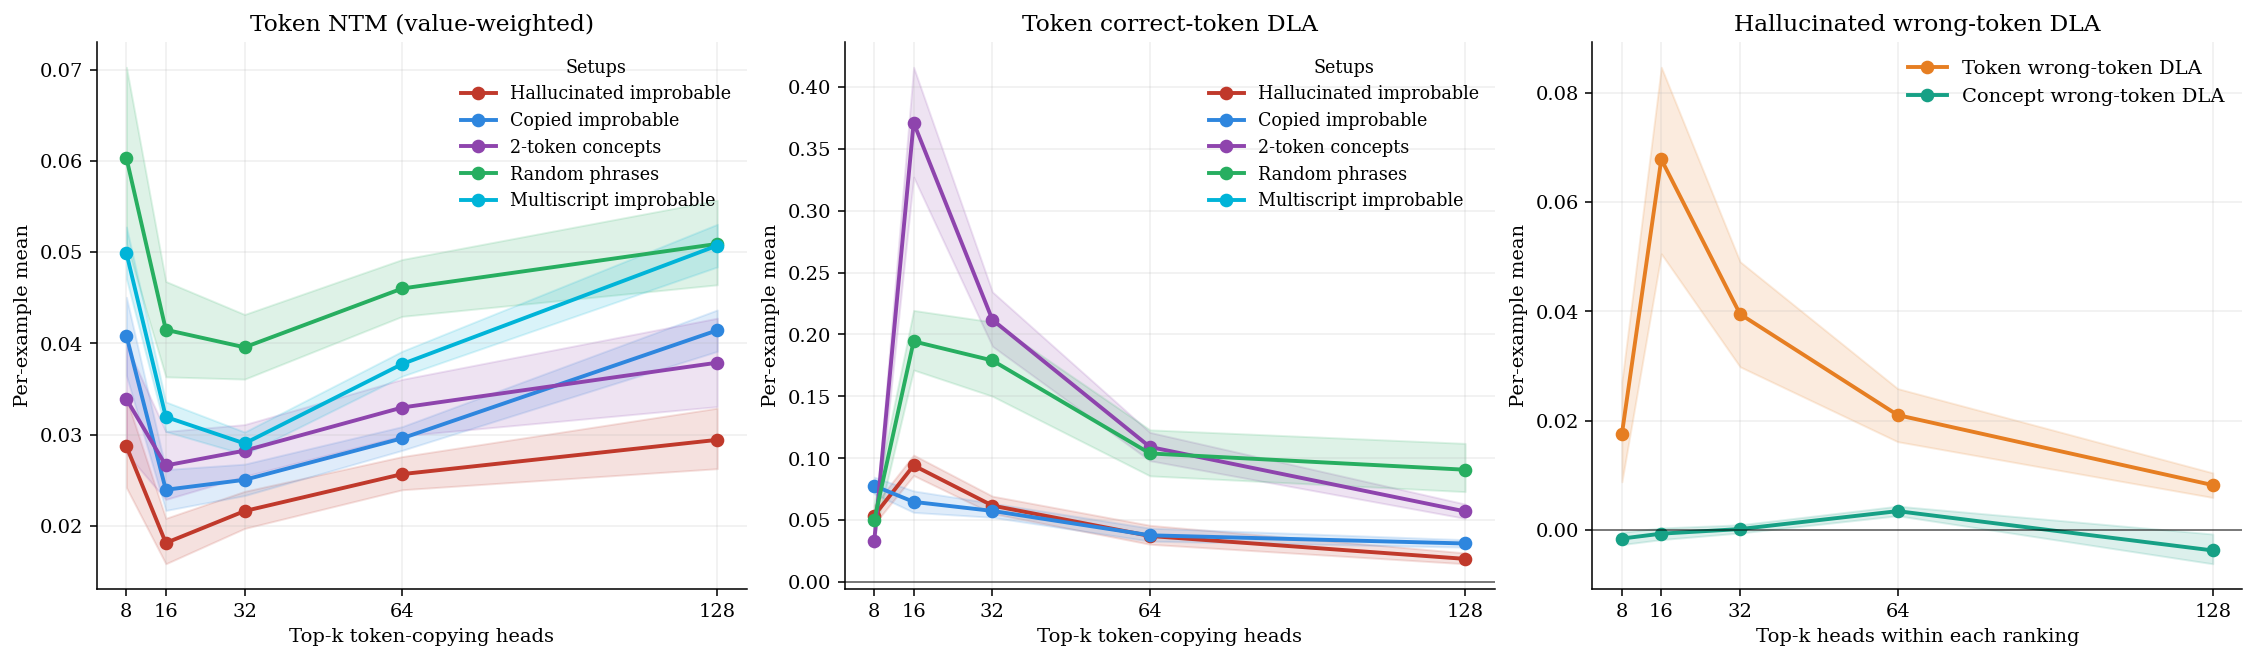

In [45]:
fig, axes, sweep = h1.plot_k_sweep(CACHE, ks=(8, 16, 32, 64, 128), weighted=WEIGHTED)
display(sweep.round(6))

(<Figure size 1680x784 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 token-head NTM (value-weighted)'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 token-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

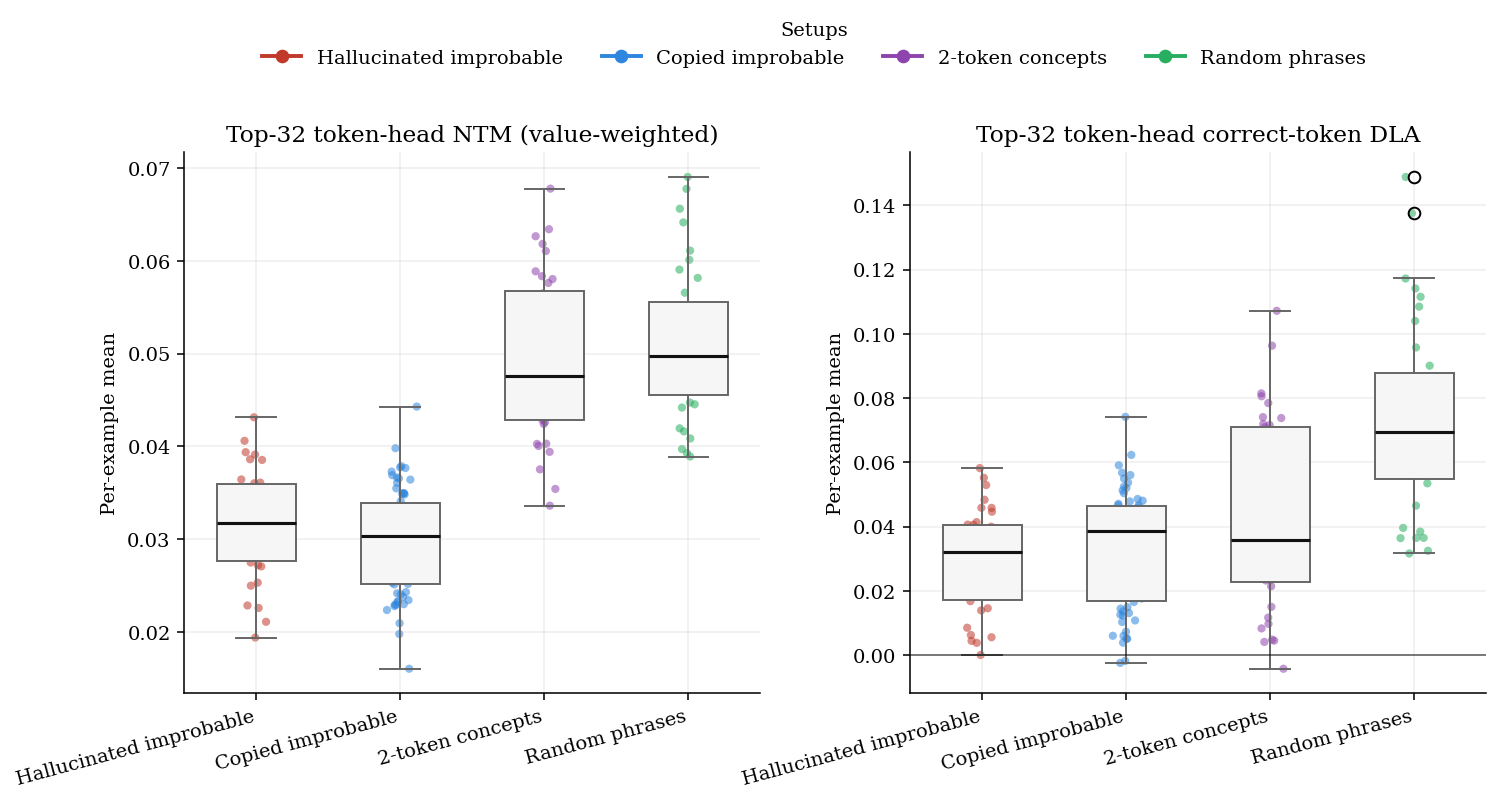

In [5]:
h1.plot_distribution_panels(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 token heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

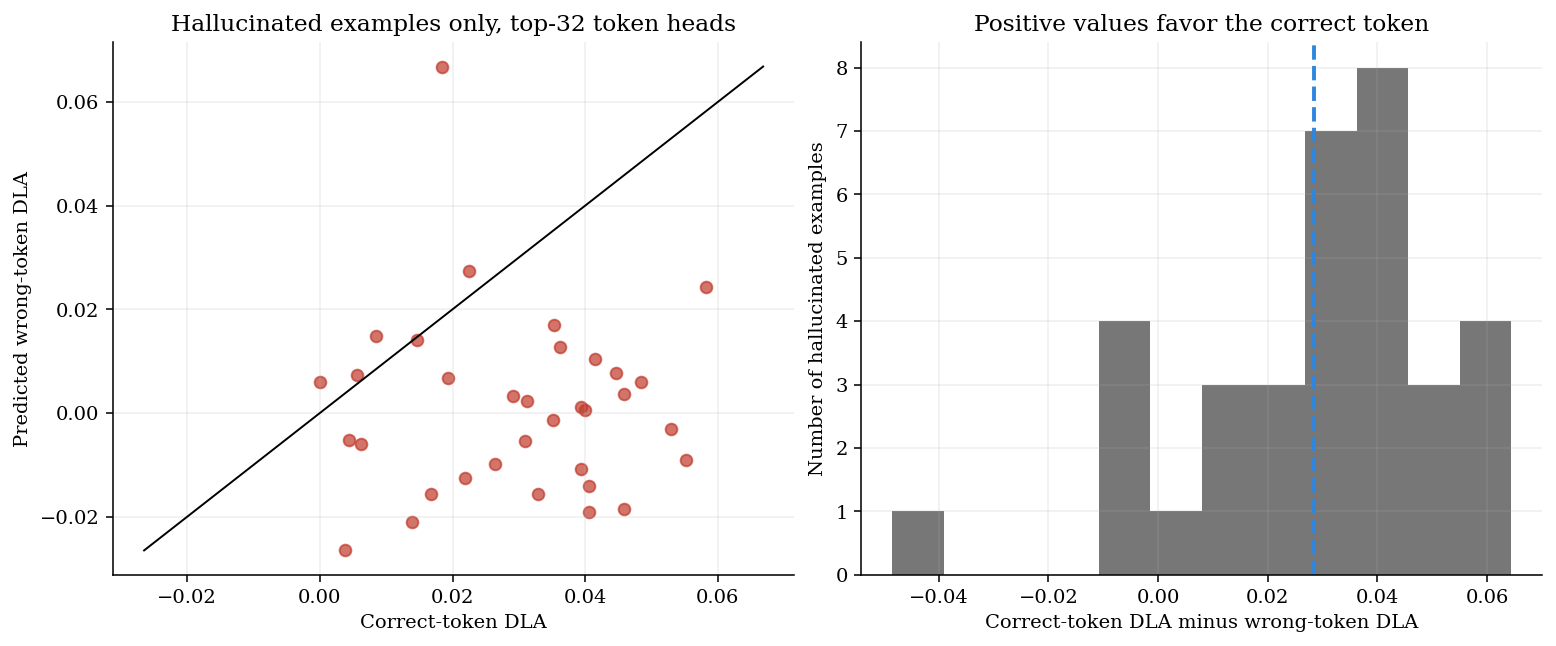

In [6]:
h1.plot_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1890x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 token heads: NTM (value-weighted)'}>,
        <Axes: title={'center': 'Top-16 token heads: DLA'}>], dtype=object))

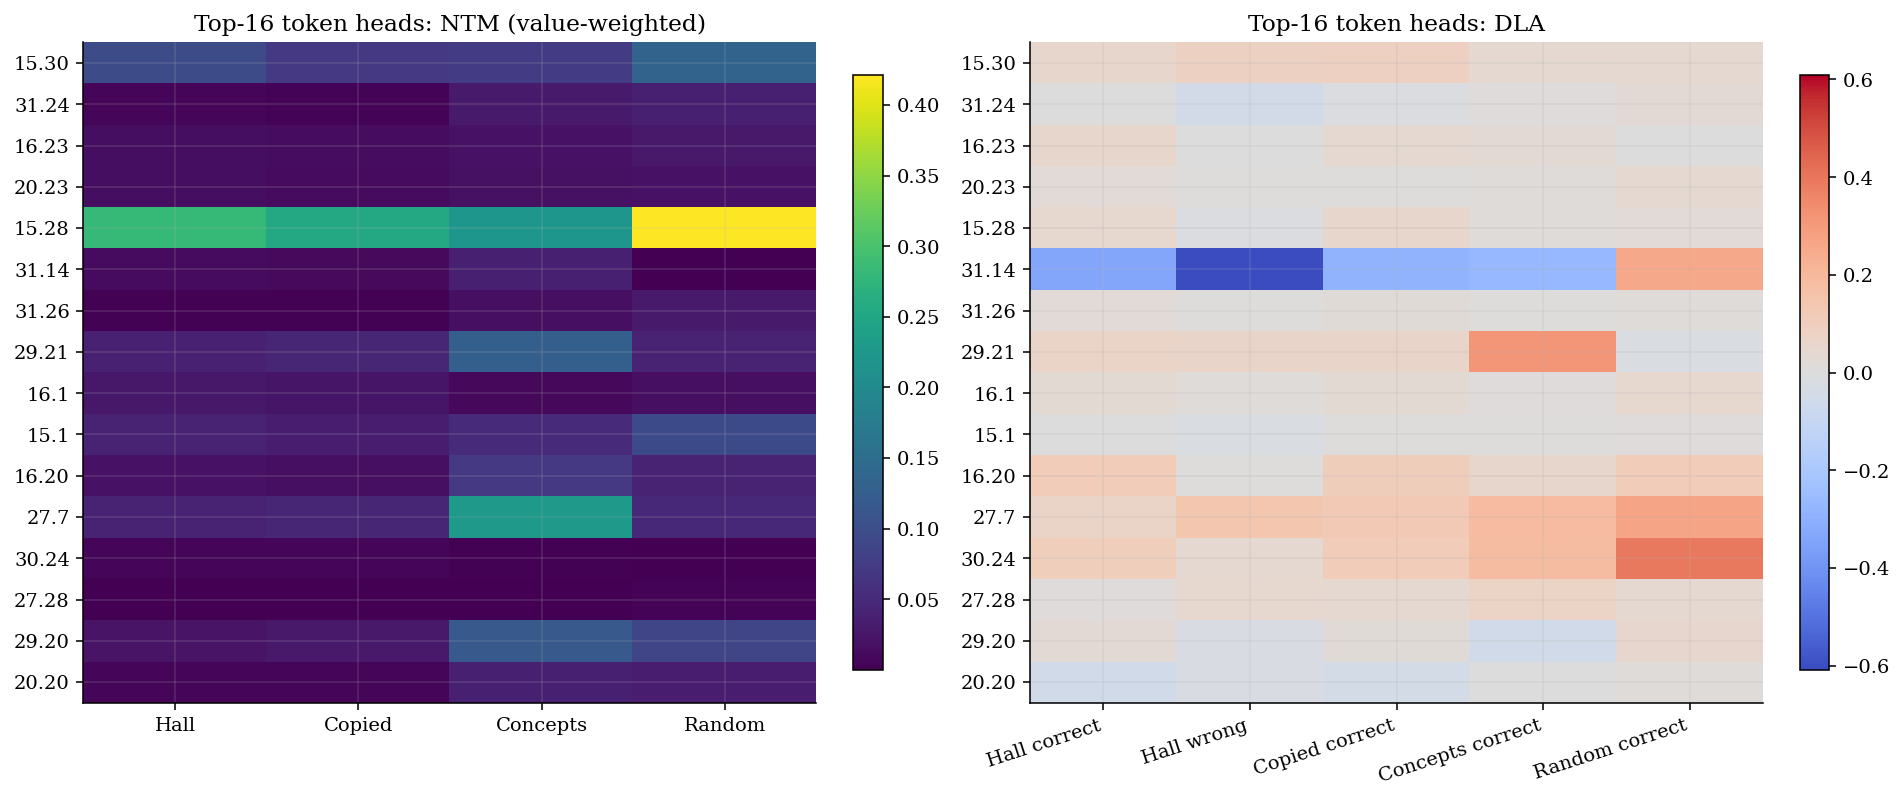

In [7]:
h1.plot_top_head_heatmap(CACHE, top_k=16, weighted=WEIGHTED)

## Are The Highest-DLA Heads Token-Copying Or Concept-Copying?

Rank heads by mean DLA on each example subset and check membership in the token-copying and concept-copying top-K rankings.

In [8]:
TOP_DLA_N = 20
COMPARE_K = 32
SOURCES = [
    "hallucinated_correct",
    "hallucinated_wrong",
    "copied_correct",
    "concepts_correct",
    "random_correct",
]

membership_summary = h1.summarize_top_dla_membership(
    CACHE,
    sources=SOURCES,
    top_n=TOP_DLA_N,
    compare_k=COMPARE_K,
)
display(membership_summary)

for source in SOURCES:
    table = h1.top_dla_membership_table(
        CACHE,
        source=source,
        top_n=TOP_DLA_N,
        compare_k=COMPARE_K,
    )
    display(Markdown(f"### {table['source'].iloc[0]}"))
    display(
        table[
            [
                "head",
                "mean_dla",
                "membership_label",
                "in_token_top_k",
                "in_concept_top_k",
                "token_rank",
                "concept_rank",
            ]
        ].round({"mean_dla": 6})
    )

,source,top_n,compare_k,token_overlap,concept_overlap,both_overlap,neither_overlap,mean_token_rank,mean_concept_rank
0,Hallucinated correct-token DLA,20,32,3,2,0,15,349.50,624.70
1,Hallucinated wrong-token DLA,20,32,3,2,0,15,345.10,676.05
2,Copied-improbable correct-token DLA,20,32,4,2,0,14,343.65,638.15
3,2-token-concept correct-token DLA,20,32,4,1,0,15,319.60,768.85
4,Random-phrase correct-token DLA,20,32,4,0,0,16,355.45,717.15


### Hallucinated correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.688305,Token only,True,False,30,955
1,27.6,0.488522,Neither,False,False,882,371
2,26.3,0.401426,Neither,False,False,36,874
3,26.13,0.364736,Neither,False,False,308,190
4,22.1,0.319401,Neither,False,False,119,607
5,20.1,0.282793,Concept only,False,True,494,8
6,24.18,0.232462,Neither,False,False,132,994
7,31.21,0.223554,Neither,False,False,441,974
8,29.9,0.216471,Neither,False,False,549,999
9,28.22,0.197484,Neither,False,False,541,914


### Hallucinated wrong-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.435099,Token only,True,False,30,955
1,24.22,0.413221,Neither,False,False,183,619
2,29.9,0.291460,Neither,False,False,549,999
3,28.0,0.241133,Neither,False,False,306,860
4,30.26,0.229119,Neither,False,False,144,926
5,31.5,0.221403,Neither,False,False,534,951
6,26.3,0.198855,Neither,False,False,36,874
7,31.21,0.197255,Neither,False,False,441,974
8,25.7,0.193913,Neither,False,False,442,789
9,27.6,0.193628,Neither,False,False,882,371


...

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.1,0.653223,Token only,True,False,30,955
1,27.6,0.501448,Neither,False,False,882,371
2,26.13,0.363669,Neither,False,False,308,190
3,26.3,0.362918,Neither,False,False,36,874
4,29.9,0.254335,Neither,False,False,549,999
5,20.1,0.239196,Concept only,False,True,494,8
6,27.20,0.235168,Concept only,False,True,192,4
7,30.12,0.232389,Neither,False,False,873,864
8,31.20,0.211272,Neither,False,False,584,960
9,31.21,0.176189,Neither,False,False,441,974


### 2-token-concept correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,30.26,0.966518,Neither,False,False,144,926
1,29.9,0.806480,Neither,False,False,549,999
2,31.1,0.764443,Token only,True,False,30,955
3,27.20,0.554755,Concept only,False,True,192,4
4,29.11,0.543800,Neither,False,False,281,667
5,28.18,0.353730,Neither,False,False,108,762
6,31.7,0.315361,Neither,False,False,479,965
7,29.21,0.312236,Token only,True,False,8,937
8,31.6,0.280483,Neither,False,False,152,946
9,30.2,0.248536,Neither,False,False,950,928


### Random-phrase correct-token DLA

,head,mean_dla,membership_label,in_token_top_k,in_concept_top_k,token_rank,concept_rank
0,31.0,0.801272,Token only,True,False,22,956
1,27.4,0.560181,Neither,False,False,522,743
2,30.12,0.420074,Neither,False,False,873,864
3,30.24,0.390628,Token only,True,False,13,831
4,28.20,0.367737,Neither,False,False,233,670
5,25.13,0.340523,Neither,False,False,697,856
6,25.14,0.339815,Neither,False,False,74,403
7,30.30,0.335793,Neither,False,False,73,889
8,24.18,0.334160,Neither,False,False,132,994
9,24.16,0.321873,Neither,False,False,411,787


PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction/scripts/llama_3_1_8b_hypothesis1_figures')

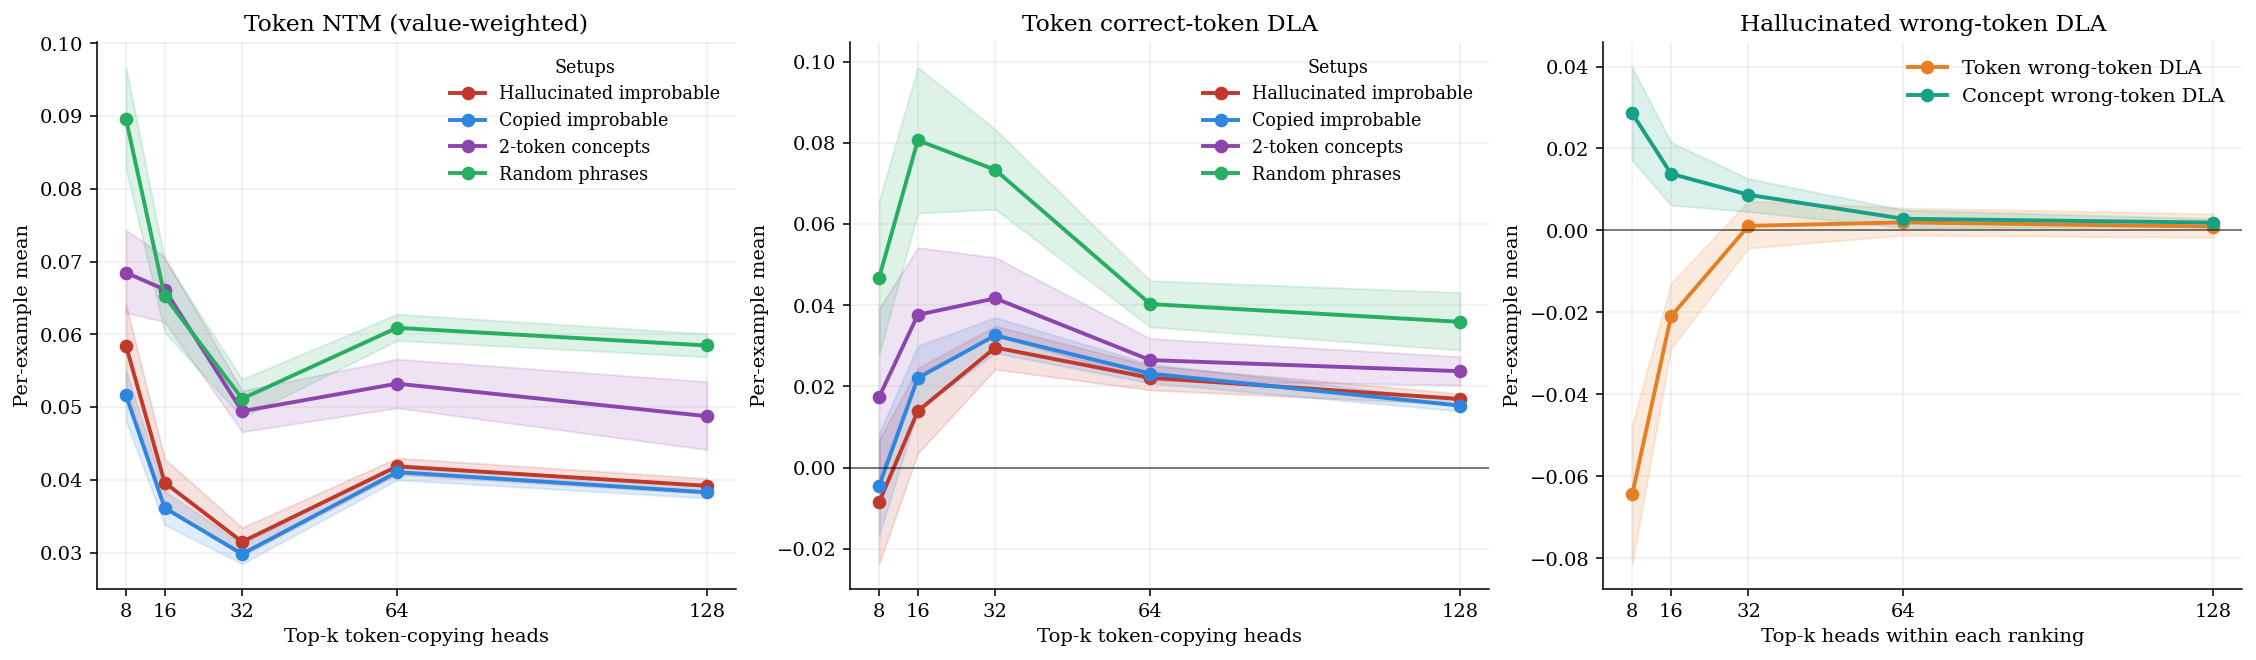

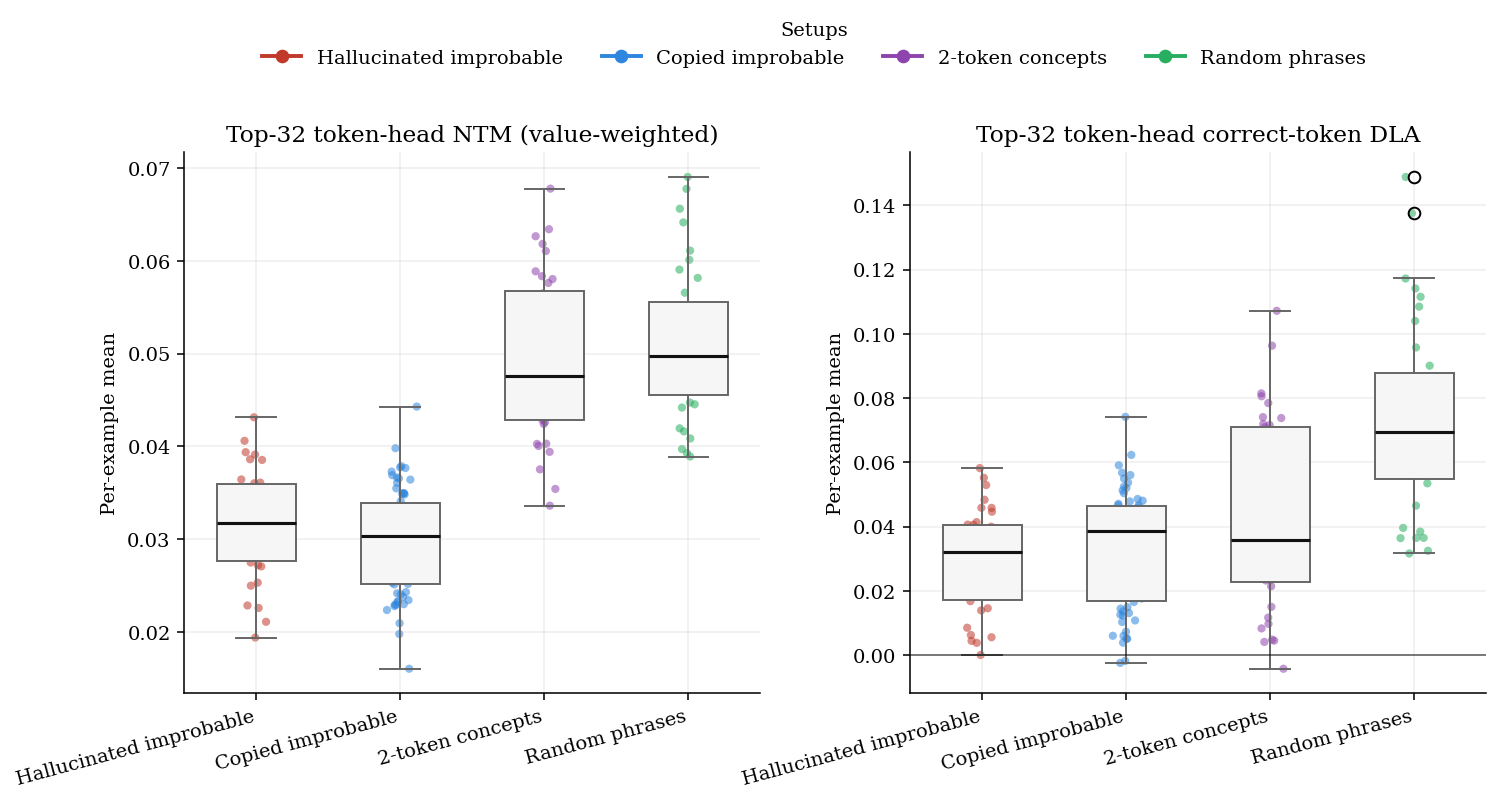

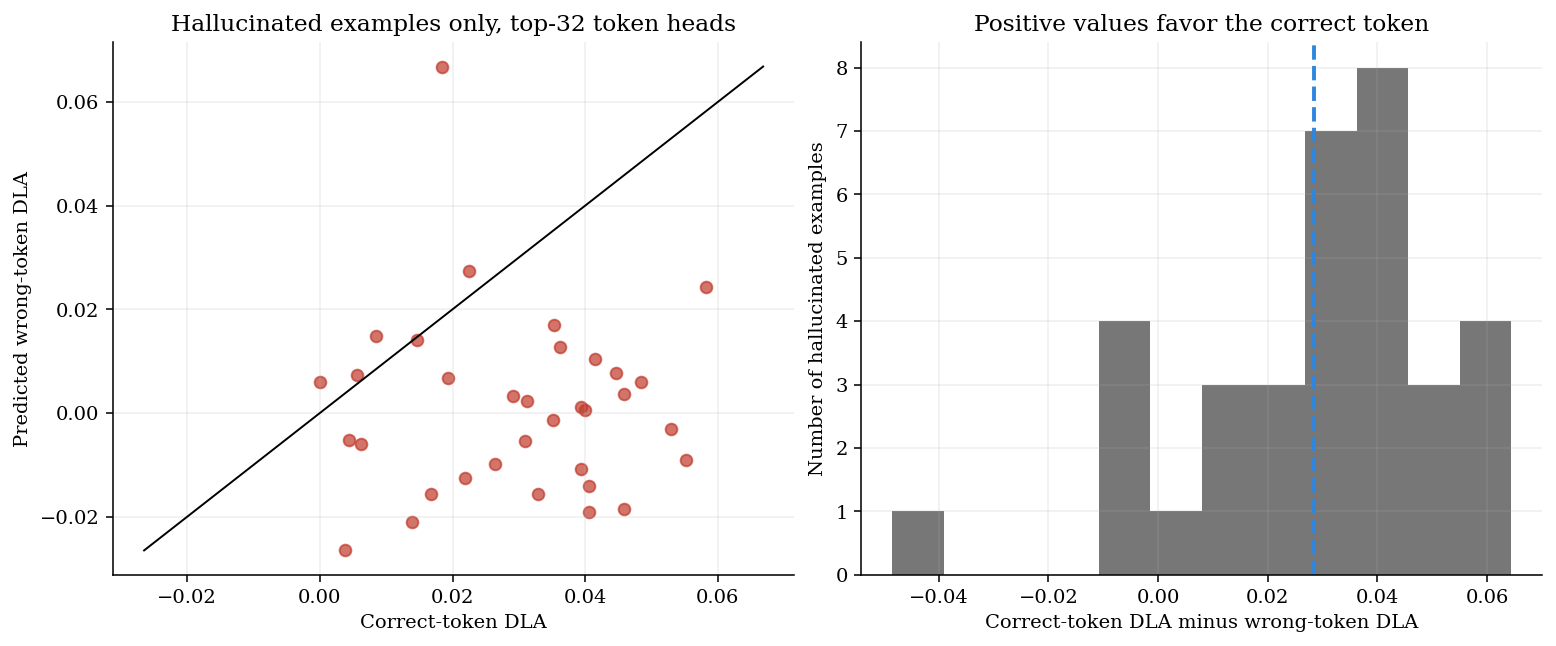

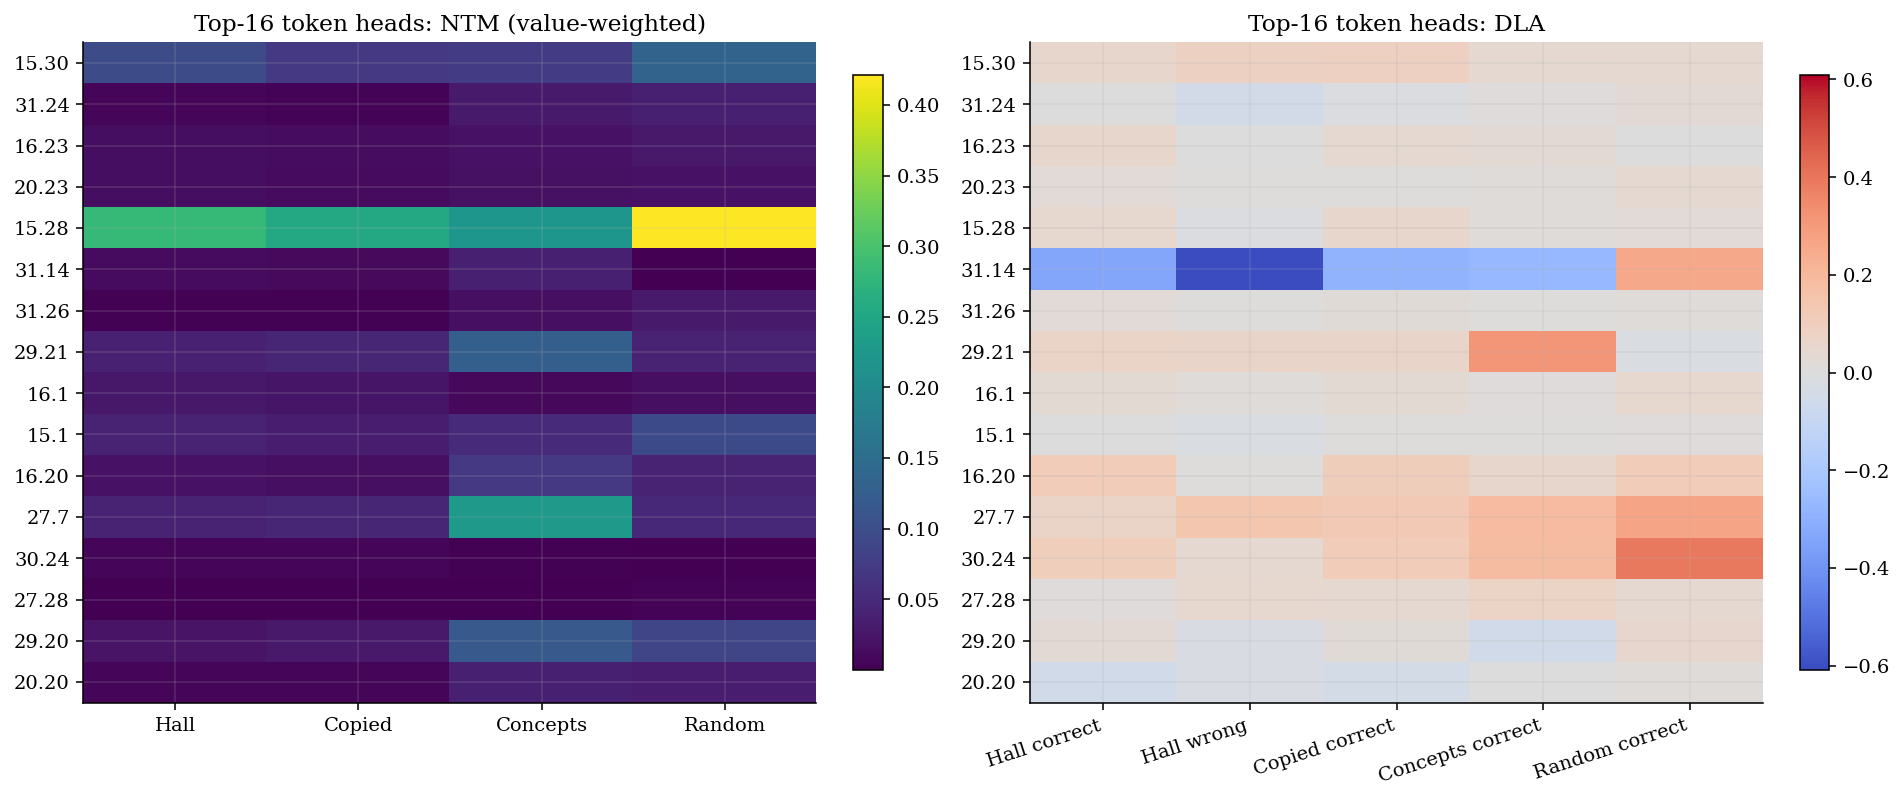

In [9]:
SAVE_DIR = ROOT / "scripts" / f"{MODEL_SLUG}_hypothesis1_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_k_sweep(
    CACHE,
    ks=(8, 16, 32, 64, 128),
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_k_sweep_{WEIGHTED_TAG}.png",
)
_ = h1.plot_distribution_panels(
    CACHE,
    DEFAULT_TOP_K,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_distributions_{WEIGHTED_TAG}.png",
)
_ = h1.plot_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "hypothesis1_hallucinated_dla_pair.png"
)
_ = h1.plot_top_head_heatmap(
    CACHE,
    top_k=16,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"hypothesis1_top_token_heads_{WEIGHTED_TAG}.png",
)
SAVE_DIR

---

# Concept-Copying Head Analysis

Mirrors `concept_copying_analysis.ipynb`. Reuses the same loaded cache and helper module.

## Coverage

Three conditions are present in the cache:

1. hallucinated improbable bigrams
2. random two-token phrases
3. coherent two-token concepts

Copied improbable examples serve as an additional internal control.

In [39]:
summary = h1.build_concept_pairwise_summary(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)
display(summary.round(6))
display(Markdown(h1.concept_interpretation_markdown(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)))

,metric,comparison,left_mean,right_mean,diff,ci_low,ci_high
0,Concept LTM (value-weighted),Hallucinated - Copied,0.061404,0.055154,0.006249,0.003017,0.009631
1,Concept LTM (value-weighted),Hallucinated - 2-token concepts,0.061404,0.073859,-0.012456,-0.015807,-0.009134
2,Concept LTM (value-weighted),Hallucinated - Random,0.061404,0.058833,0.002570,-0.001276,0.006460
3,Concept correct-token DLA,Hallucinated - Copied,0.012357,0.011425,0.000932,-0.004799,0.006388
4,Concept correct-token DLA,Hallucinated - 2-token concepts,0.012357,0.040961,-0.028605,-0.052241,-0.007523
5,Concept correct-token DLA,Hallucinated - Random,0.012357,0.019316,-0.006960,-0.017426,0.002584
6,Hallucinated concept DLA,Wrong-token - Correct-token,0.017106,0.012357,0.004749,-0.004691,0.013824


### Concept-Head Readout at Top-32
- Hallucinated vs copied LTM: `0.0062` (95% CI `0.0030` to `0.0096`)
- Hallucinated vs copied correct-token DLA: `0.0009` (95% CI `-0.0048` to `0.0064`)
- Hallucinated vs 2-token concepts LTM: `-0.0125` (95% CI `-0.0158` to `-0.0091`)
- Hallucinated vs 2-token concepts correct-token DLA: `-0.0286` (95% CI `-0.0522` to `-0.0075`)
- Hallucinated vs random LTM: `0.0026` (95% CI `-0.0013` to `0.0065`)
- Hallucinated vs random correct-token DLA: `-0.0070` (95% CI `-0.0174` to `0.0026`)
- Hallucinated wrong-token minus correct-token DLA: `0.0047` (95% CI `-0.0047` to `0.0138`)

The current cache includes hallucinated improbable bigrams, copied improbable prompts, coherent 2-token concepts, and random two-token phrases. That allows a direct check of whether concept-head behavior on hallucinated prompts looks more like the coherent concept condition or like the random-token control. In the current traced cache, concept heads do not cleanly separate hallucinated prompts from both copied improbable prompts and coherent 2-token concepts, and they do not strongly favor the wrong token over the correct token in hallucinated cases.

,metric,condition,k,mean,ci_low,ci_high
0,Concept LTM (value-weighted),Hallucinated improbable,8,0.055378,0.048486,0.062422
1,Concept LTM (value-weighted),Copied improbable,8,0.045604,0.041466,0.049676
2,Concept LTM (value-weighted),2-token concepts,8,0.054191,0.047212,0.061044
3,Concept LTM (value-weighted),Random phrases,8,0.032644,0.028191,0.037285
4,Concept LTM (value-weighted),Hallucinated improbable,16,0.062532,0.058323,0.067167
5,Concept LTM (value-weighted),Copied improbable,16,0.056885,0.054435,0.059334
6,Concept LTM (value-weighted),2-token concepts,16,0.070884,0.066742,0.074937
7,Concept LTM (value-weighted),Random phrases,16,0.060130,0.056735,0.063590
8,Concept LTM (value-weighted),Hallucinated improbable,32,0.061404,0.058784,0.064026
9,Concept LTM (value-weighted),Copied improbable,32,0.055154,0.053162,0.057184


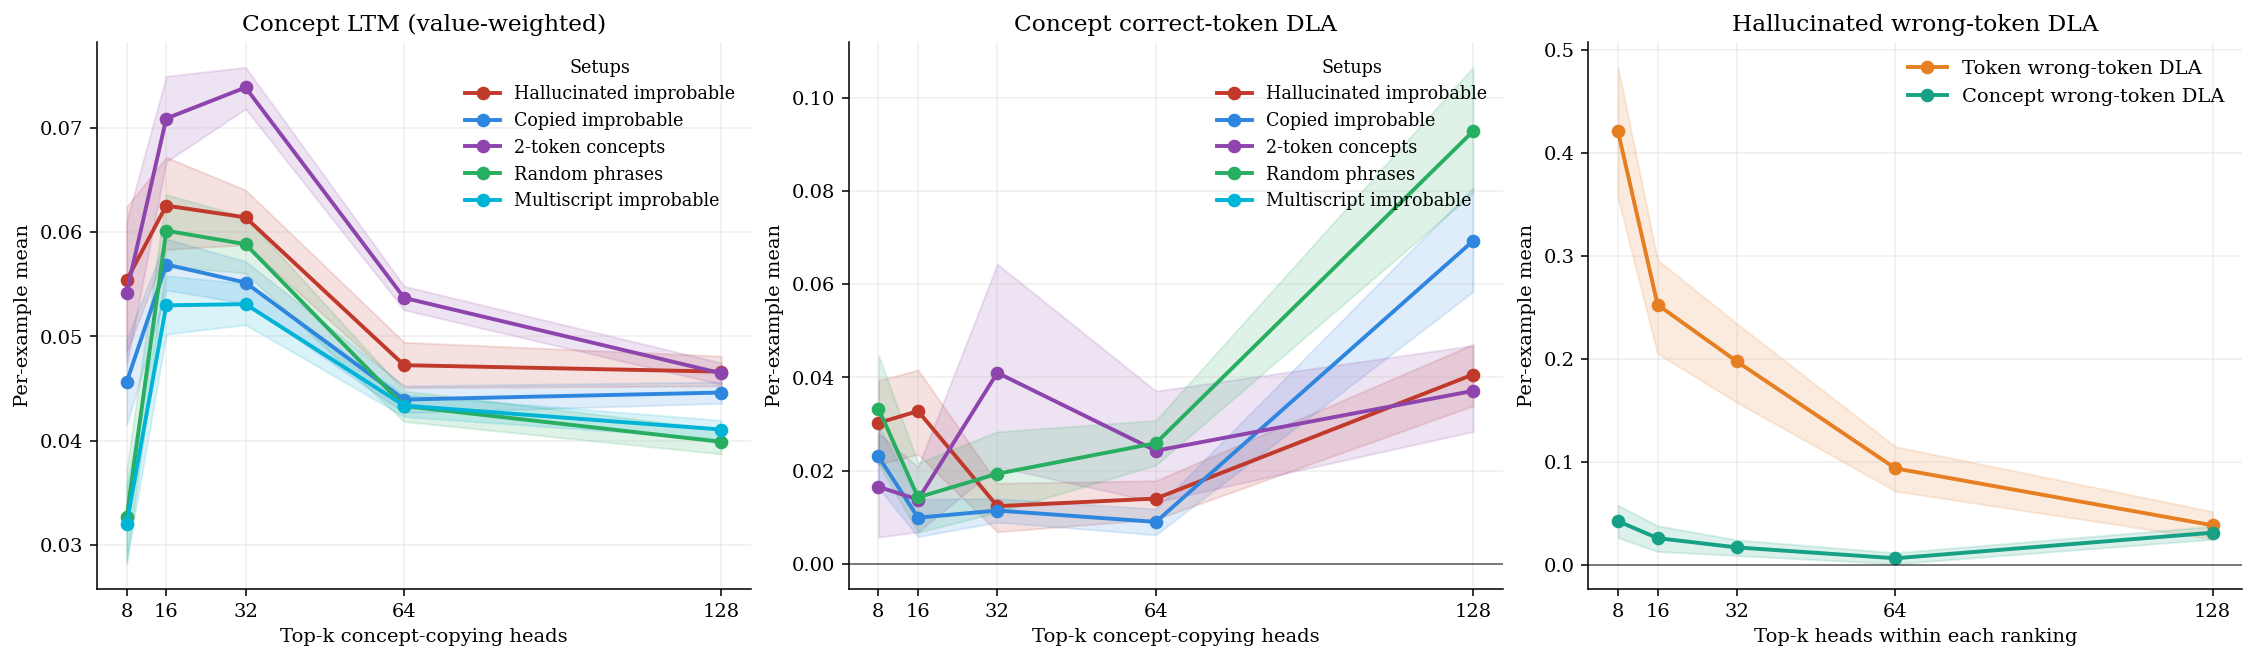

In [40]:
fig, axes, sweep = h1.plot_concept_k_sweep(CACHE, ks=(8, 16, 32, 64, 128), weighted=WEIGHTED)
display(sweep.round(6))

(<Figure size 1680x784 with 2 Axes>,
 array([<Axes: title={'center': 'Top-32 concept-head LTM (value-weighted)'}, ylabel='Per-example mean'>,
        <Axes: title={'center': 'Top-32 concept-head correct-token DLA'}, ylabel='Per-example mean'>],
       dtype=object))

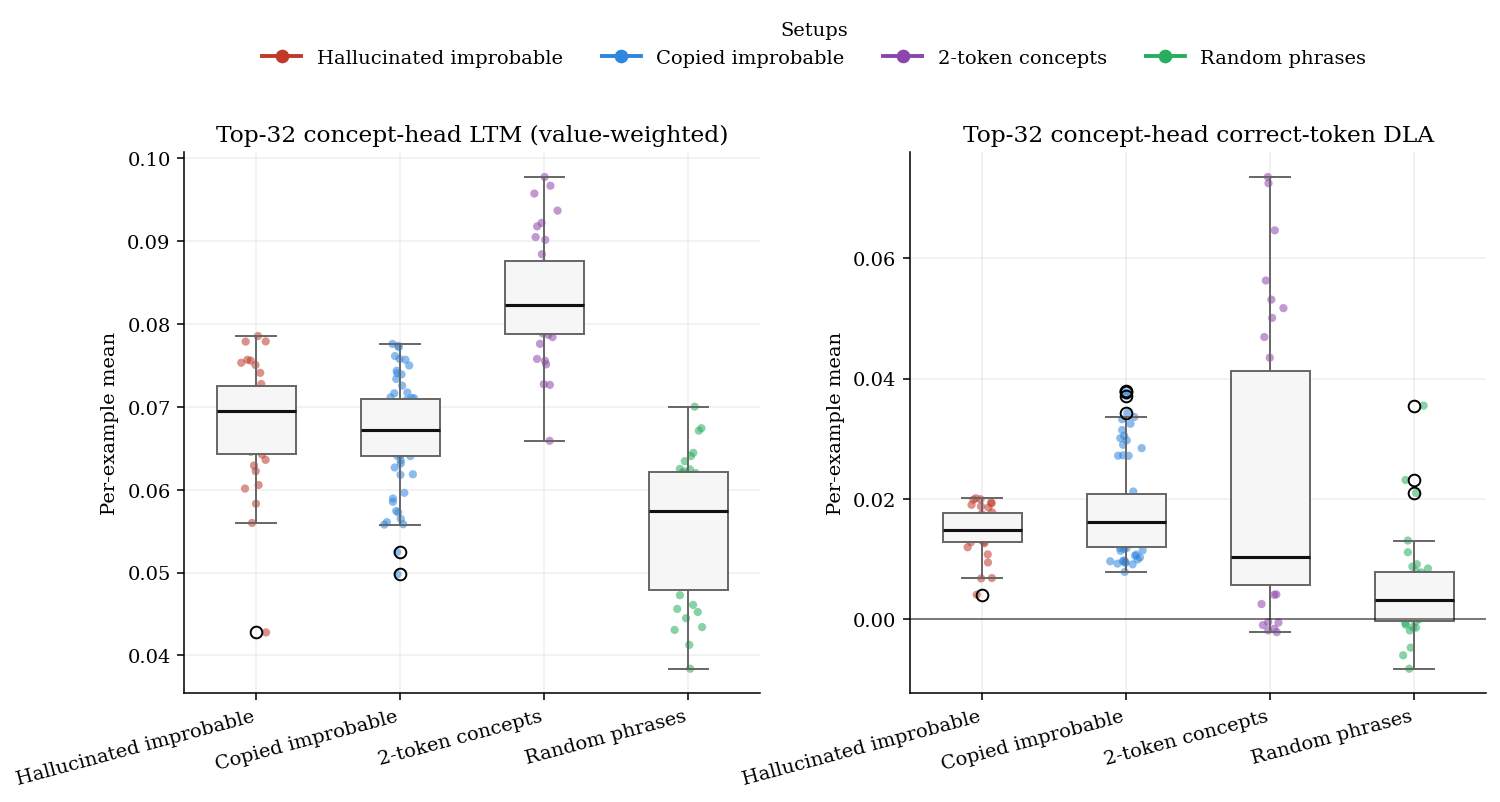

In [12]:
h1.plot_concept_distribution_panels(CACHE, DEFAULT_TOP_K, weighted=WEIGHTED)

(<Figure size 1540x630 with 2 Axes>,
 array([<Axes: title={'center': 'Hallucinated examples only, top-32 concept heads'}, xlabel='Correct-token DLA', ylabel='Predicted wrong-token DLA'>,
        <Axes: title={'center': 'Positive values favor the correct token'}, xlabel='Correct-token DLA minus wrong-token DLA', ylabel='Number of hallucinated examples'>],
       dtype=object))

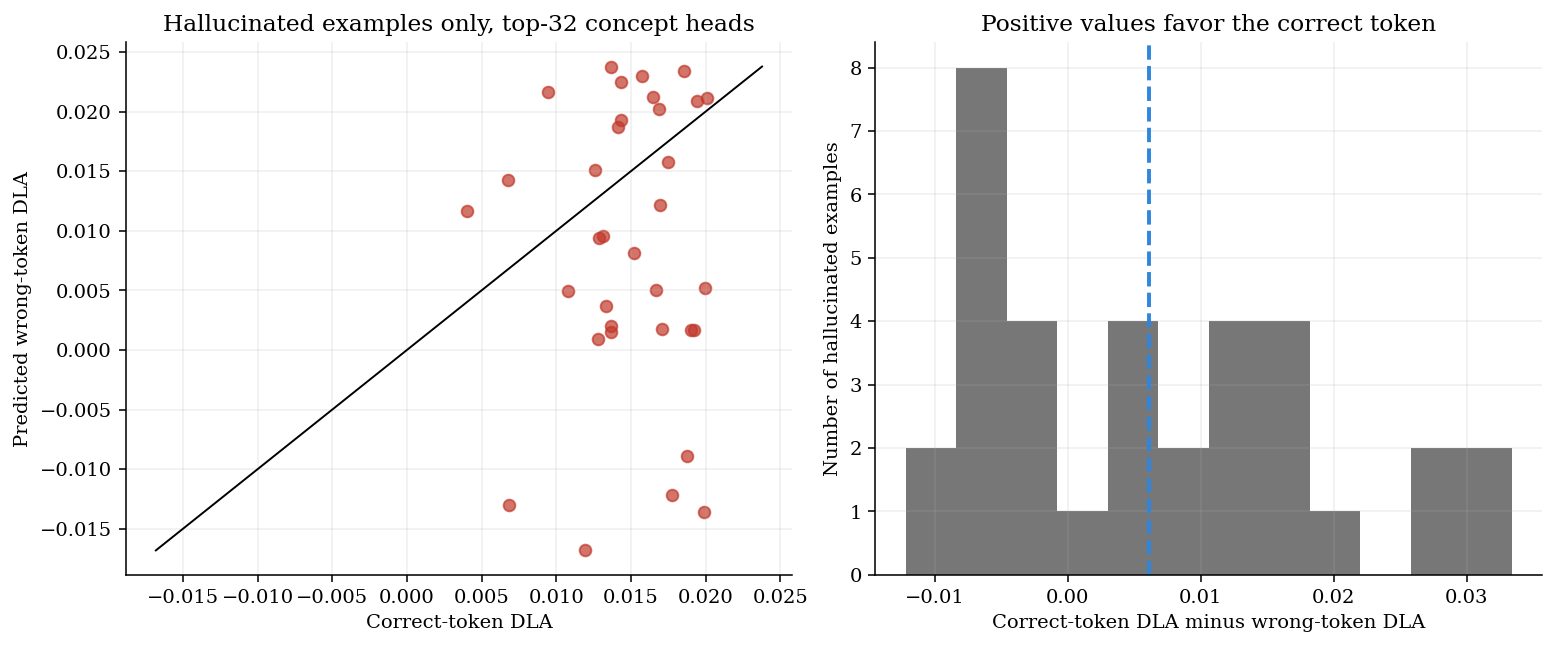

In [13]:
h1.plot_concept_hallucinated_dla_pair(CACHE, DEFAULT_TOP_K)

(<Figure size 1890x784 with 4 Axes>,
 array([<Axes: title={'center': 'Top-16 concept heads: LTM (value-weighted)'}>,
        <Axes: title={'center': 'Top-16 concept heads: DLA'}>],
       dtype=object))

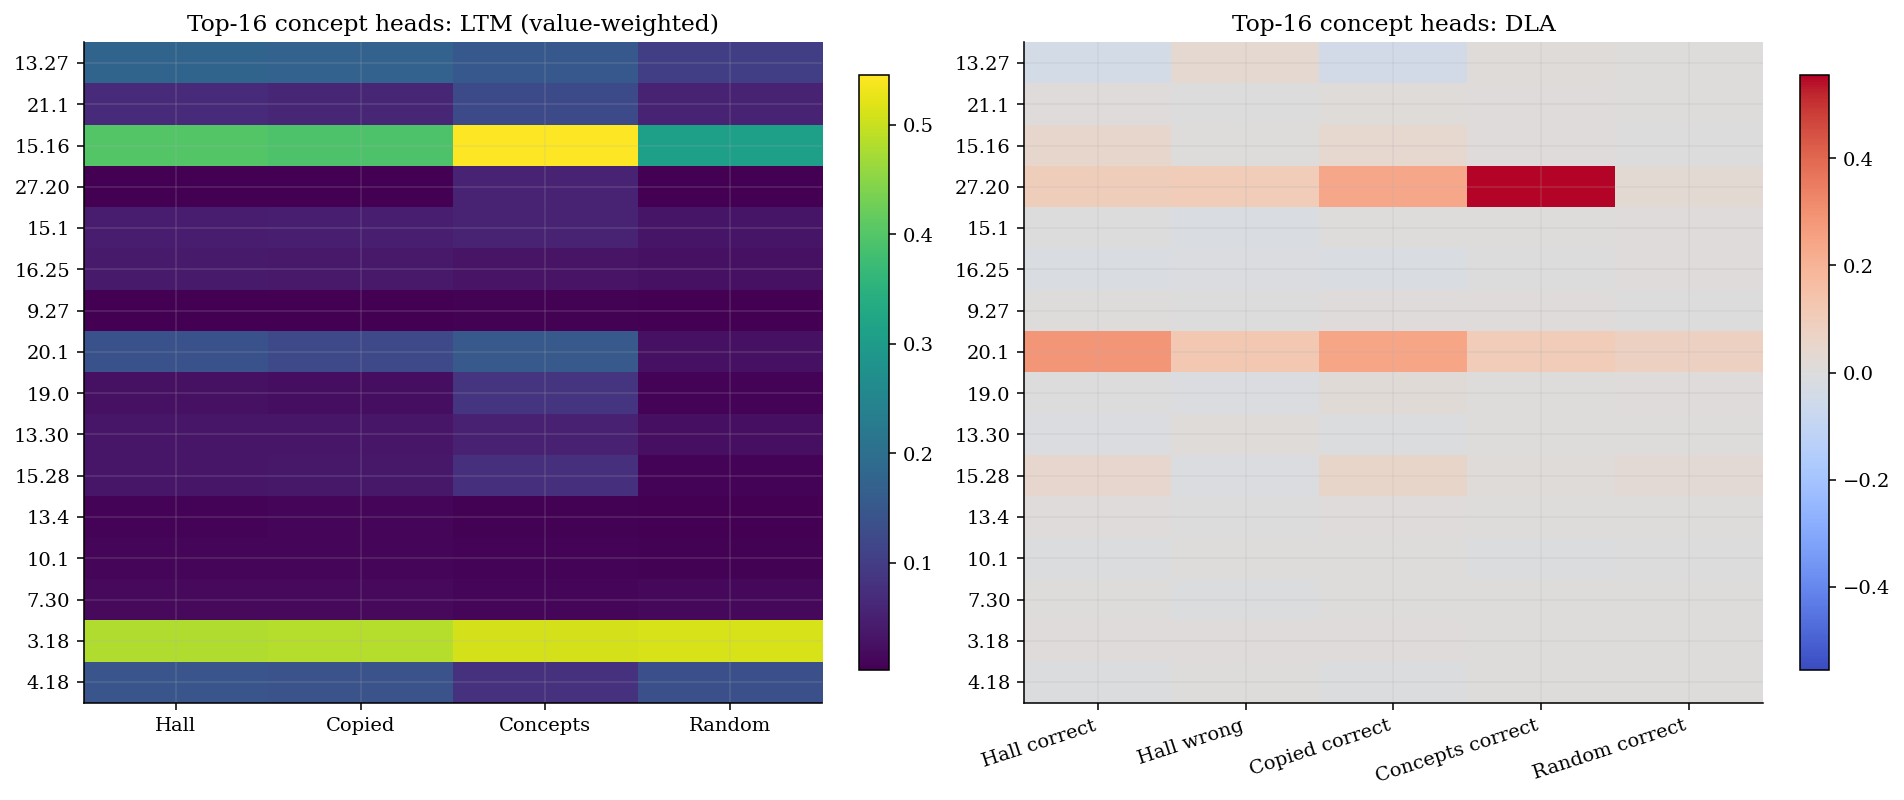

In [14]:
h1.plot_concept_head_heatmap(CACHE, top_k=16, weighted=WEIGHTED)

PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction/scripts/llama_3_1_8b_concept_head_figures')

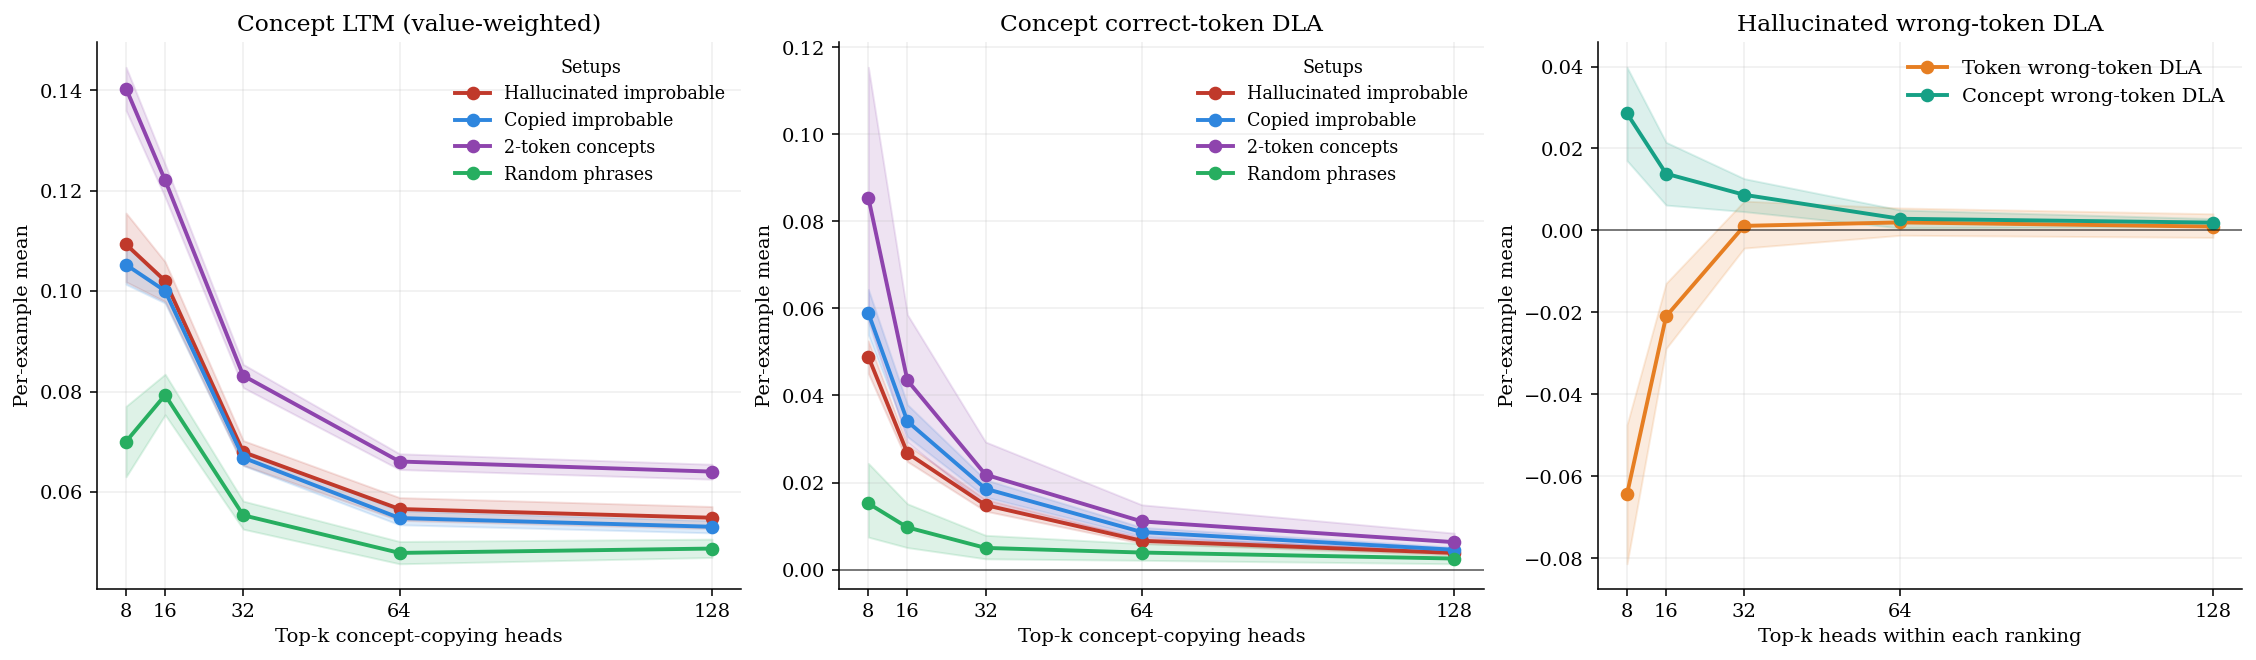

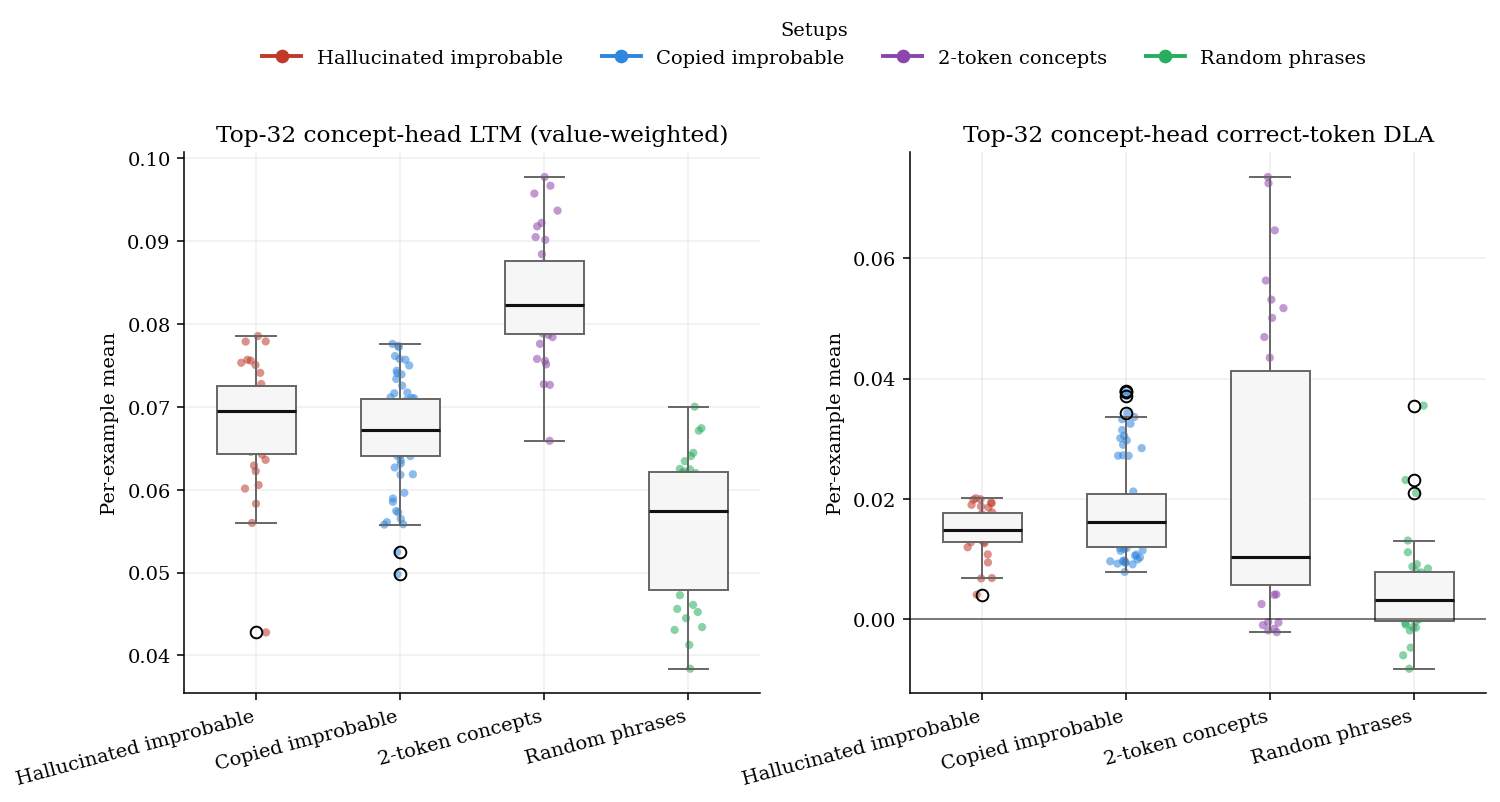

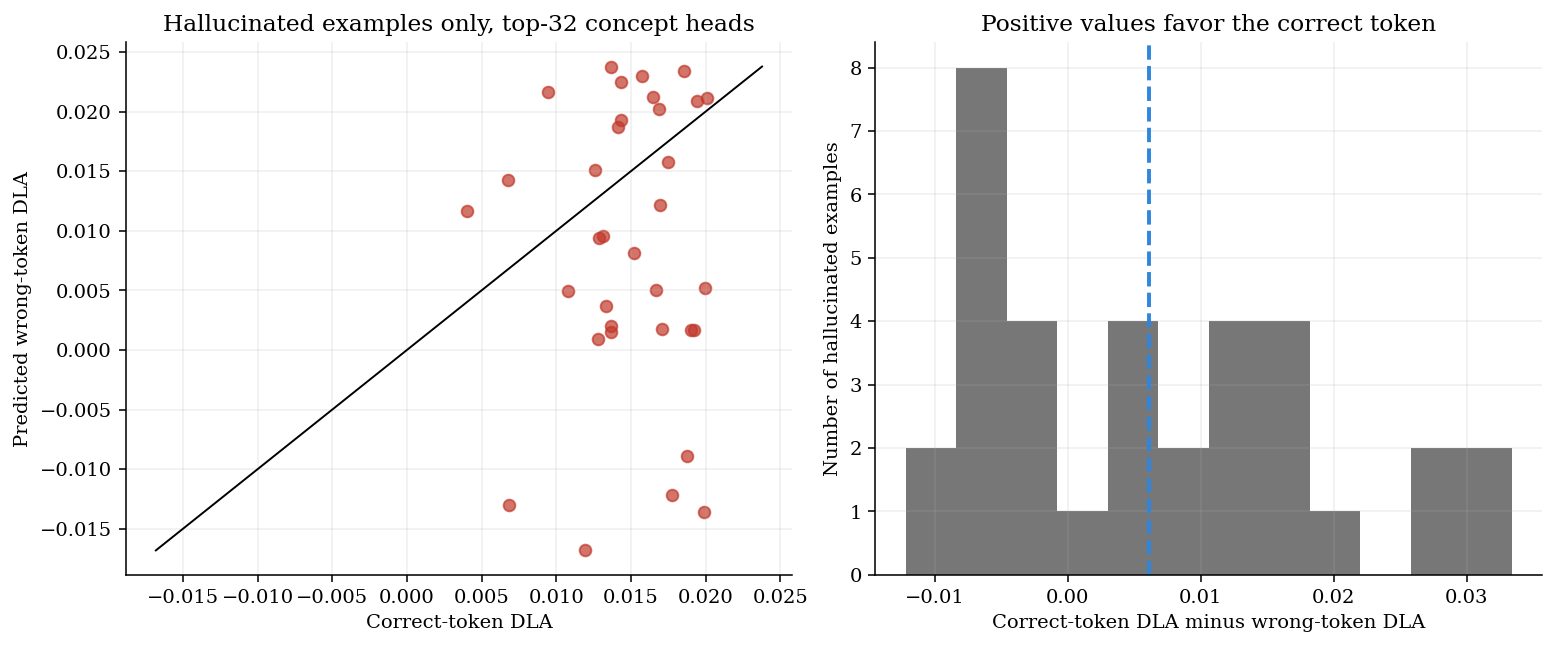

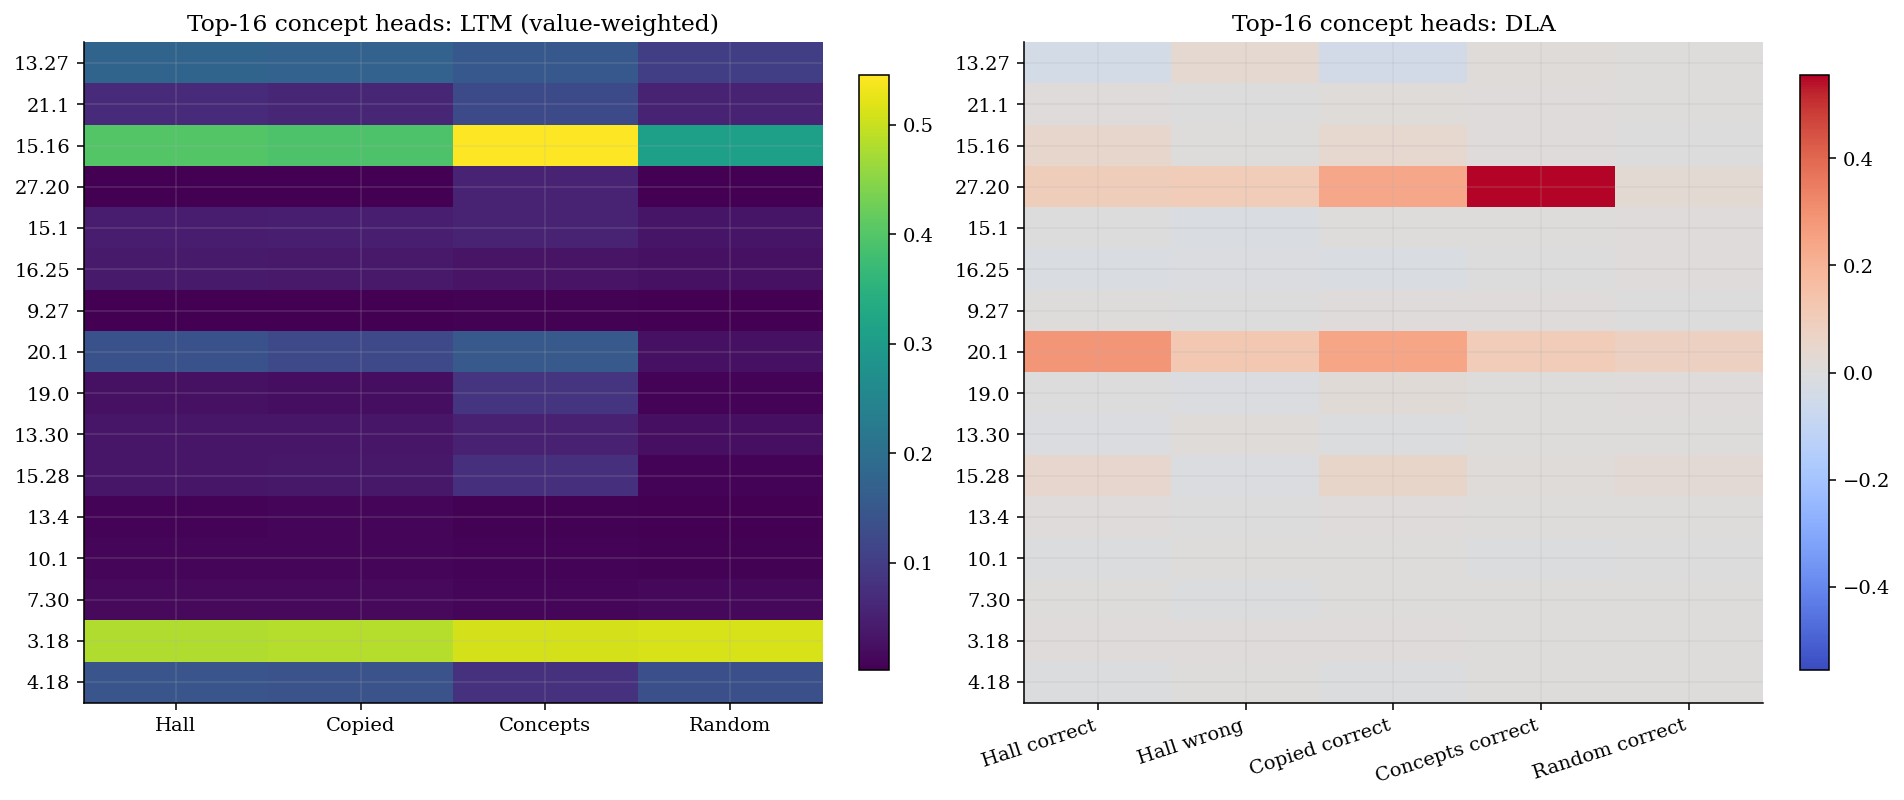

In [15]:
SAVE_DIR = ROOT / "scripts" / f"{MODEL_SLUG}_concept_head_figures"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_concept_k_sweep(
    CACHE,
    ks=(8, 16, 32, 64, 128),
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_k_sweep_{WEIGHTED_TAG}.png",
)
_ = h1.plot_concept_distribution_panels(
    CACHE,
    DEFAULT_TOP_K,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_distributions_{WEIGHTED_TAG}.png",
)
_ = h1.plot_concept_hallucinated_dla_pair(
    CACHE, DEFAULT_TOP_K, save_path=SAVE_DIR / "concept_hallucinated_dla_pair.png"
)
_ = h1.plot_concept_head_heatmap(
    CACHE,
    top_k=16,
    weighted=WEIGHTED,
    save_path=SAVE_DIR / f"concept_top_heads_{WEIGHTED_TAG}.png",
)
SAVE_DIR

---

# Vocablist Ablation Analysis

How much do concept-copying heads vs token-copying heads contribute to different
list-completion tasks?

- **`fr-en`**: French → English translation — tests conceptual/semantic association
- **`copy`**: English → English copying — tests pure token-level induction
- **`title`**: lower → Title Case — tests a surface-level transformation

Each curve shows task accuracy as heads are ablated in ranked order (concept-copying
or token-copying rank). All three models are compared side by side.

Run `slurm/slurm_vocablist_ablation.sh` to populate `cache/vocablist_ablation/`
before executing these cells.

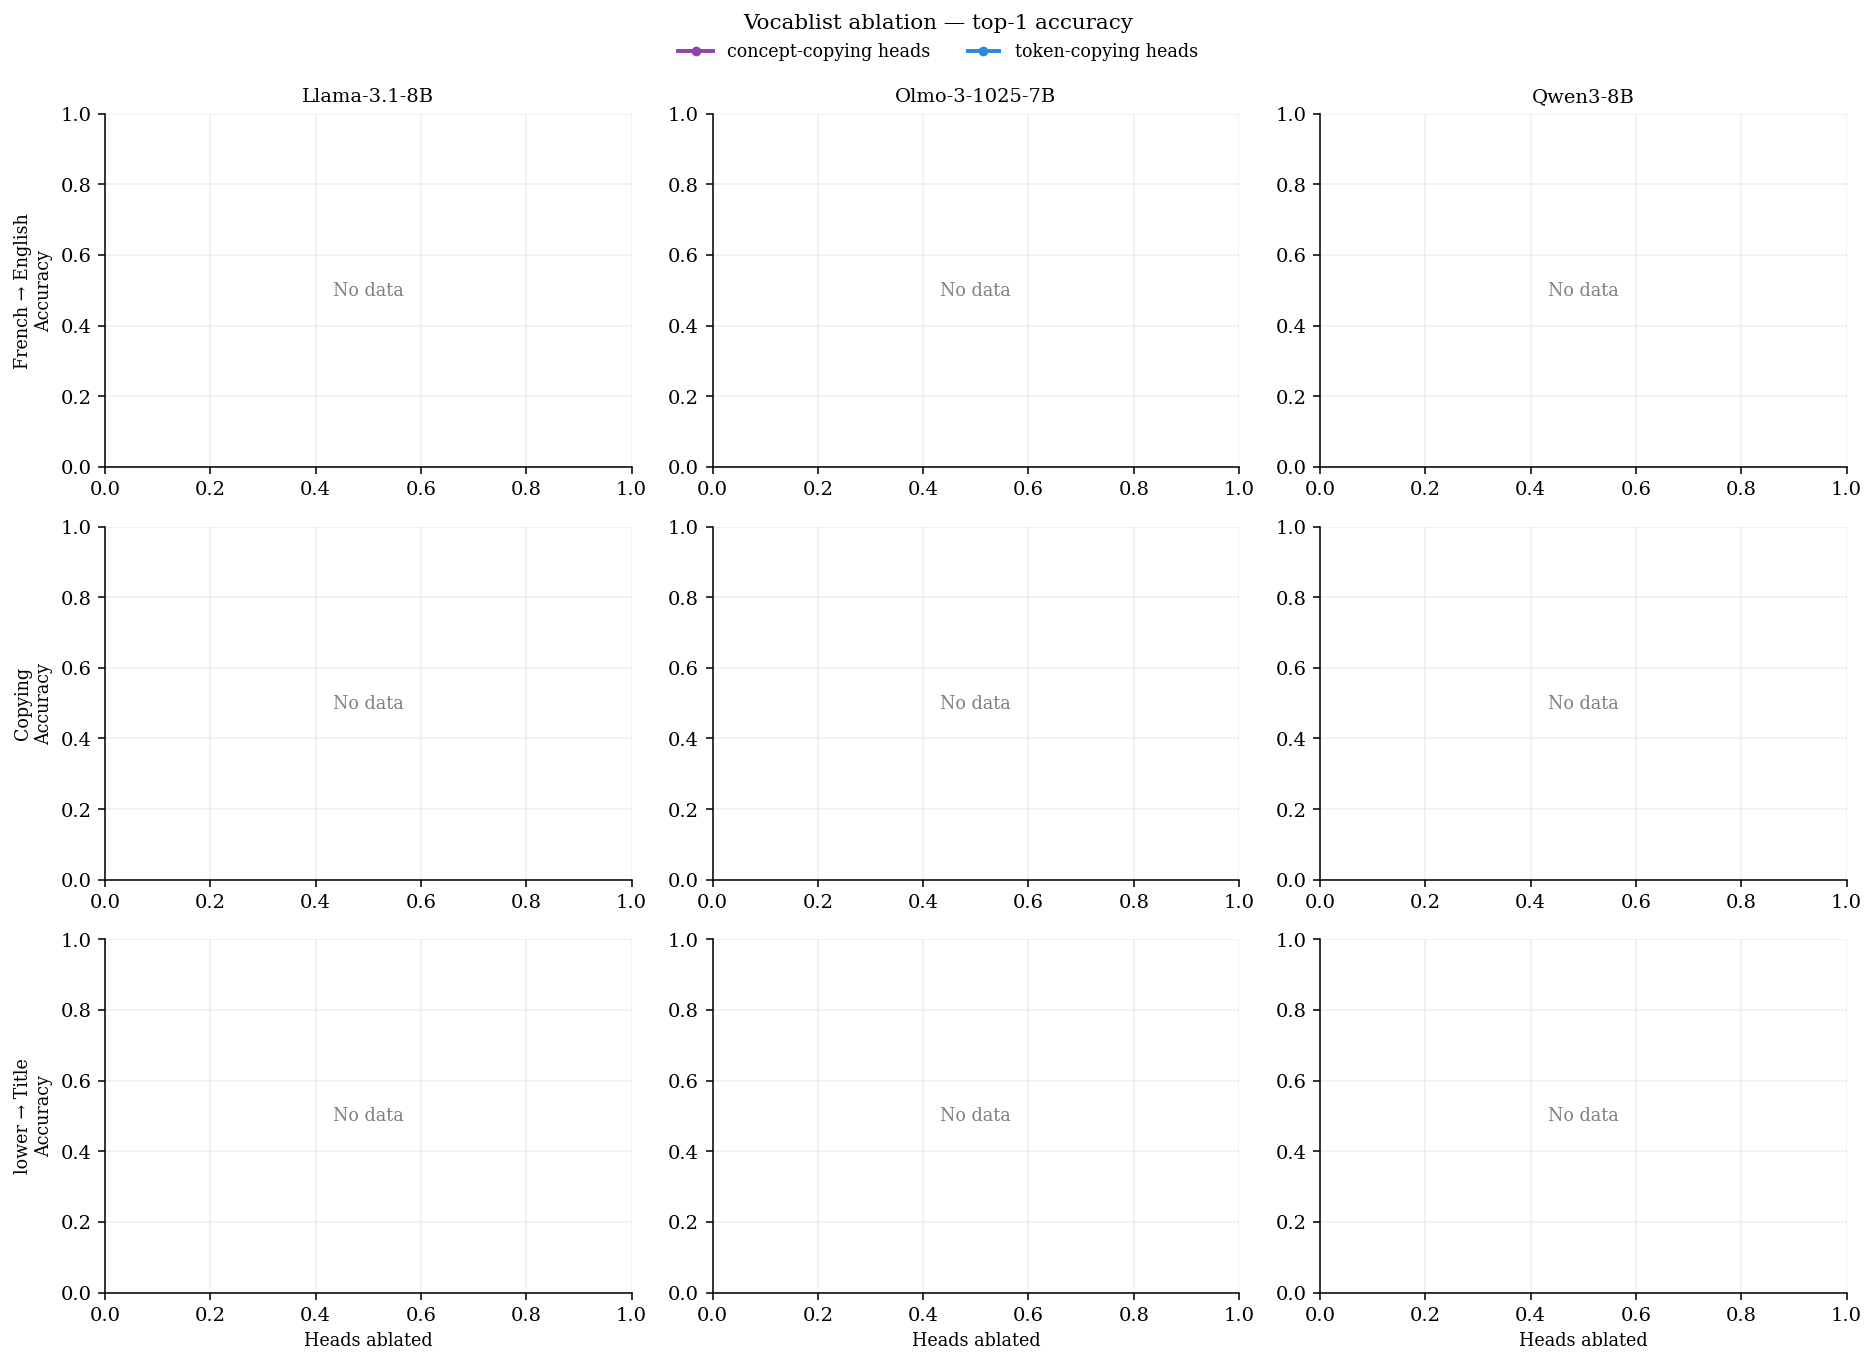

In [16]:
ABLATION_MODELS = ["Llama-3.1-8B", "Olmo-3-1025-7B", "Qwen3-8B"]
ABLATION_TASKS = ["fr-en", "copy", "title"]
ABLATION_ORDERINGS = ["concept_copying", "token_copying"]

fig_abl, _ = h1.plot_ablation_curves(
    ROOT,
    models=ABLATION_MODELS,
    tasks=ABLATION_TASKS,
    head_orderings=ABLATION_ORDERINGS,
    metric="accs",
    x_max=128,
)

PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction/scripts/ablation_figures')

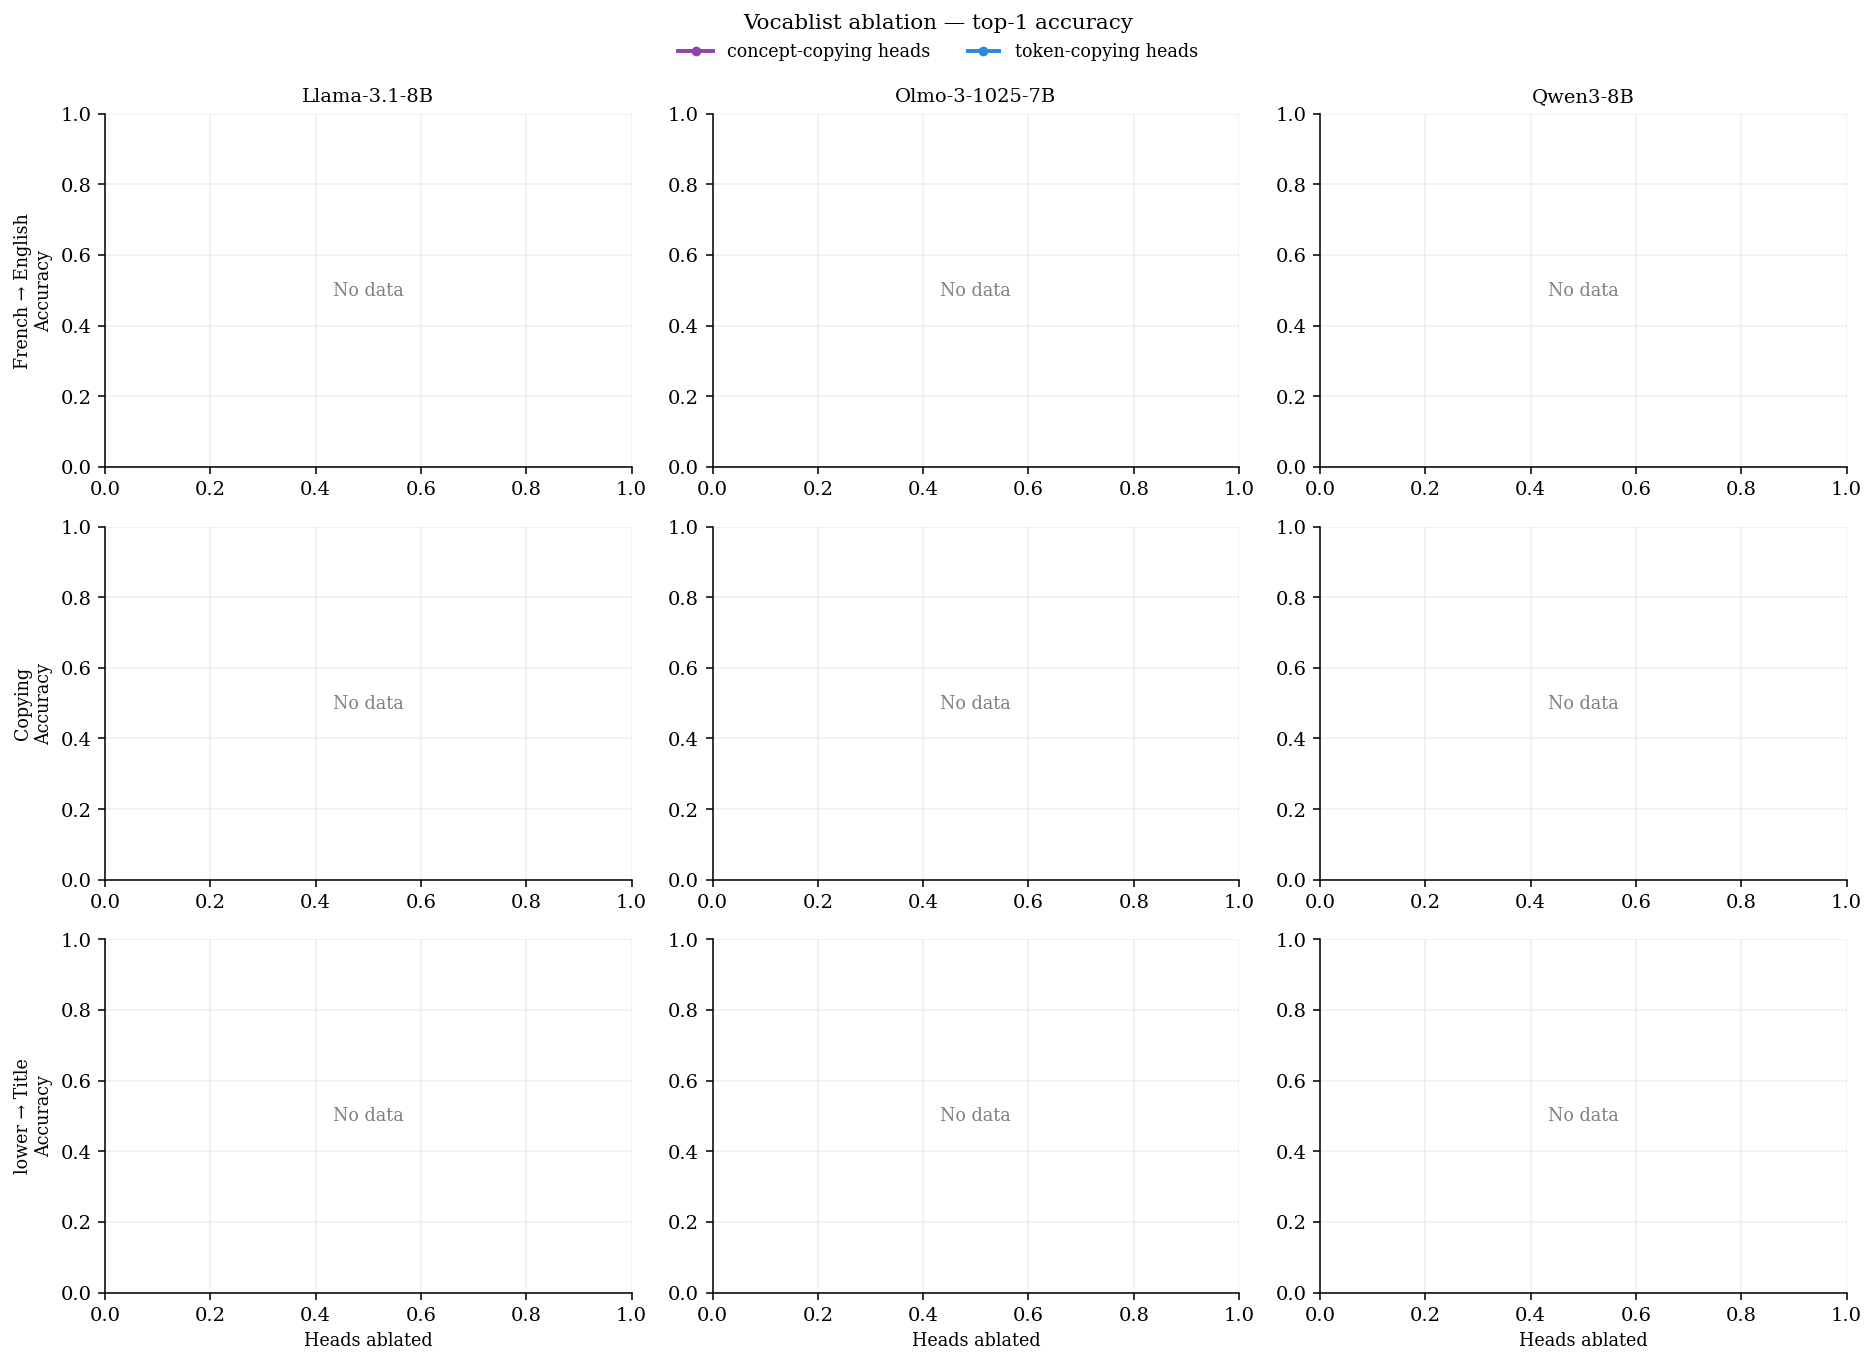

In [17]:
ABLATION_SAVE_DIR = ROOT / "scripts" / "ablation_figures"
ABLATION_SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_ablation_curves(
    ROOT,
    models=ABLATION_MODELS,
    tasks=ABLATION_TASKS,
    head_orderings=ABLATION_ORDERINGS,
    metric="accs",
    x_max=128,
    save_path=ABLATION_SAVE_DIR / "vocablist_ablation_all_models.png",
)
ABLATION_SAVE_DIR

---

# Improbable-Bigram Ablation Analysis

Mean-ablate top-k concept or token heads and measure how the hallucination
rate changes relative to the no-ablation baseline.

- **Hallucination**: model correctly predicts the prefix token (p1) but predicts
  the wrong suffix token (p2) — the bigram association fires but gets the second
  token wrong.
- **Copy success**: both p1 and p2 are predicted correctly.

If concept-copying heads are causal for hallucination, ablating them should
reduce hallucination rate; ablating token-copying heads should not.

Run `slurm/slurm_compute_mean_activations.sh` then
`slurm/slurm_improbable_bigram_ablation.sh` to populate
`cache/ablation/` before executing these cells.

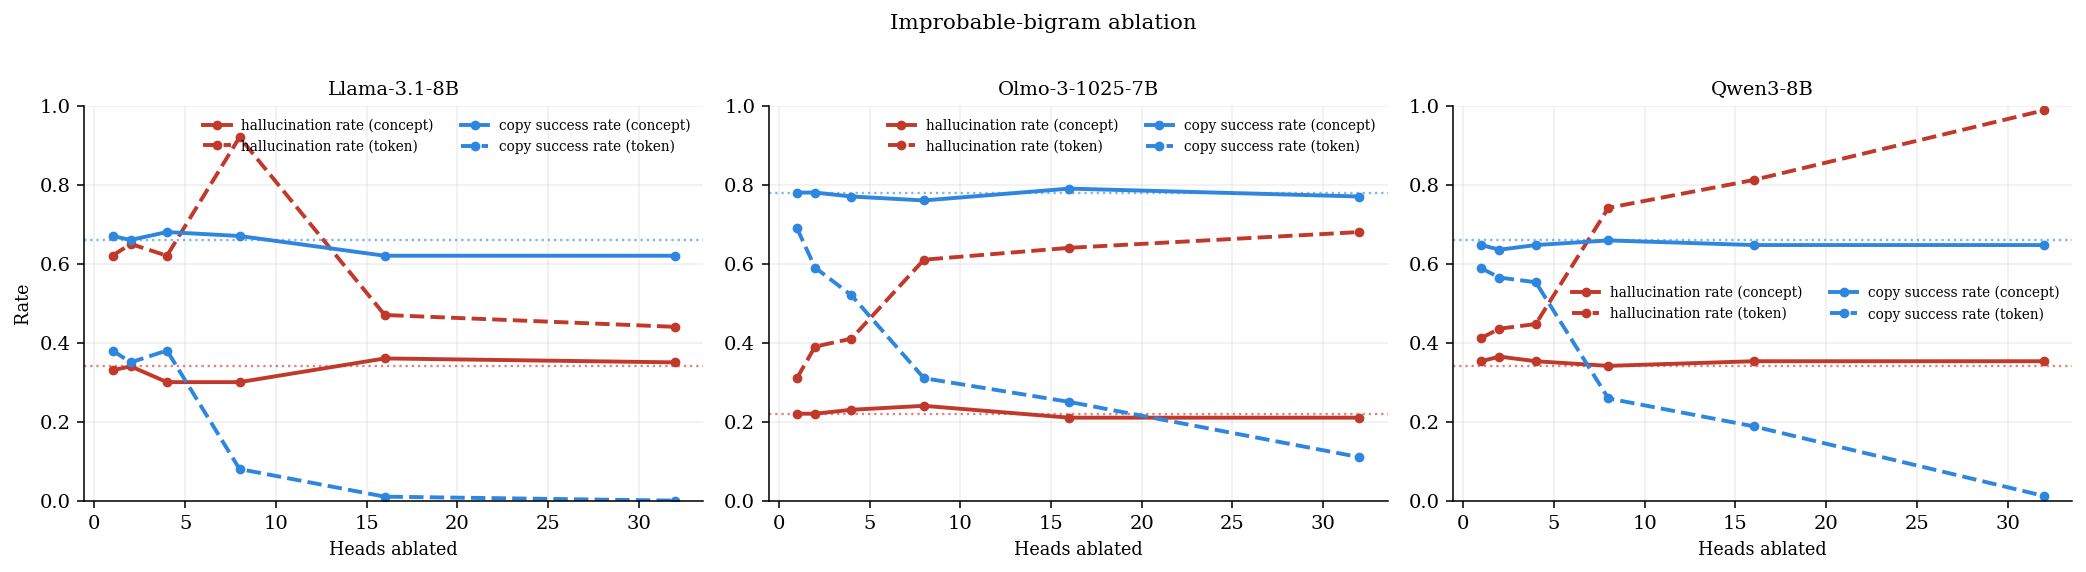

In [24]:
BIGRAM_ABLATION_MODELS = ["Llama-3.1-8B", "Olmo-3-1025-7B", "Qwen3-8B"]

fig_abl, _ = h1.plot_bigram_ablation_curves(
    ROOT,
    models=BIGRAM_ABLATION_MODELS,
)


PosixPath('/u/sahuja1/improbable-bigram-causality/dual-route-induction/scripts/ablation_figures')

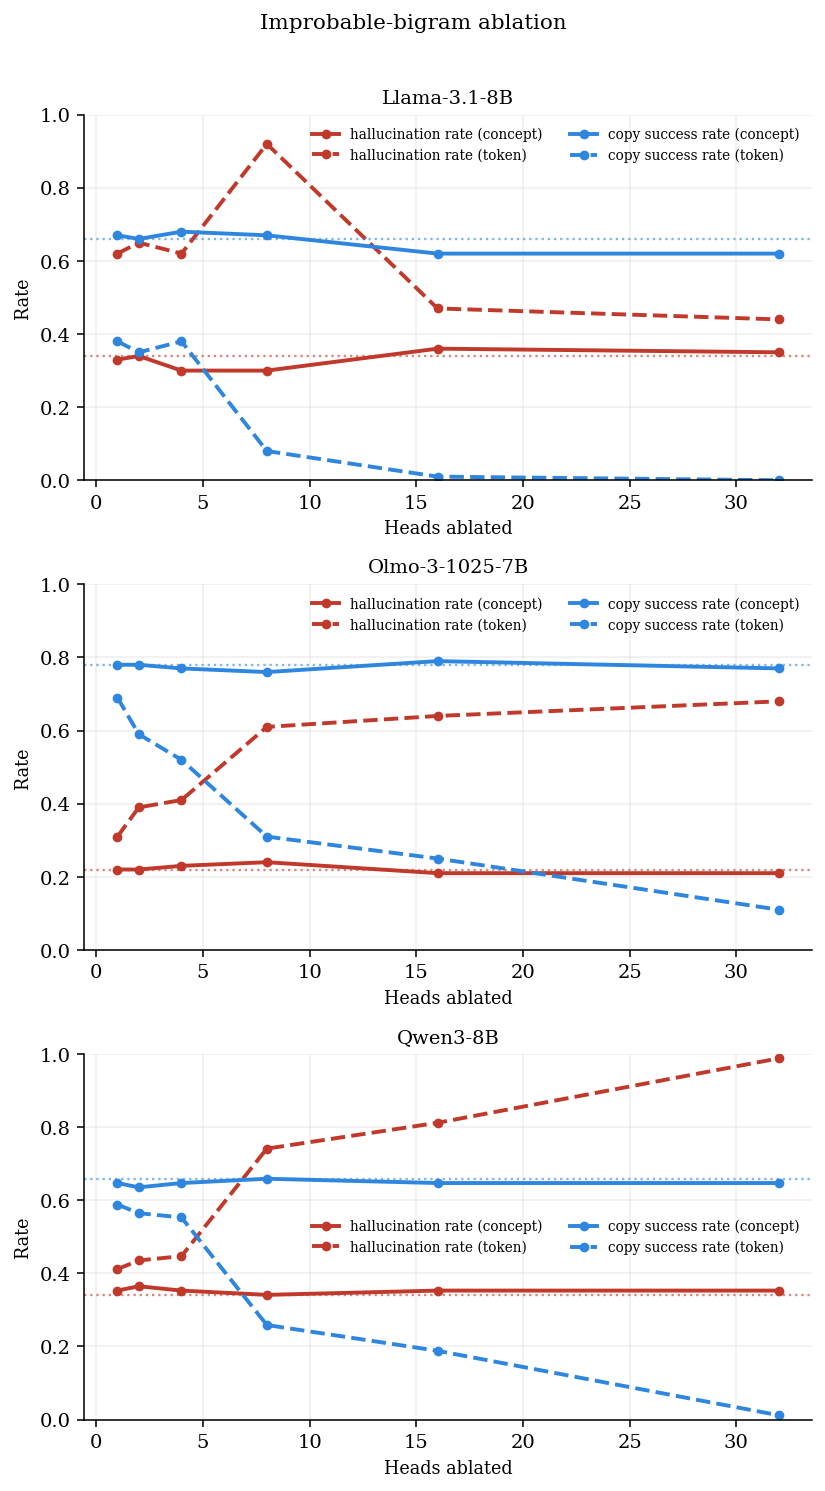

In [22]:
BIGRAM_ABLATION_SAVE_DIR = ROOT / "scripts" / "ablation_figures"
BIGRAM_ABLATION_SAVE_DIR.mkdir(parents=True, exist_ok=True)

_ = h1.plot_bigram_ablation_curves(
    ROOT,
    models=BIGRAM_ABLATION_MODELS,
    save_path=BIGRAM_ABLATION_SAVE_DIR / "bigram_ablation_all_models.png",
)
BIGRAM_ABLATION_SAVE_DIR
